In [1]:
# ---------------------------------------------------------- 0.1 installs
!pip install -q "monai[nibabel,skimage,tqdm,einops]>=1.3.0"
!pip install -q nibabel scikit-learn joblib
print("installs done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 5.9 MB/s eta 0:00:0000:0100:01
installs done


In [2]:
# --------------------------------------------- 2.1 imports & determinism
import os, sys, re, json, glob, time, random, shutil, warnings, math
from pathlib import Path
from dataclasses import dataclass, field, asdict
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from tqdm.auto import tqdm

import monai
from monai.data import (Dataset, CacheDataset, PersistentDataset, DataLoader,
                        decollate_batch, MetaTensor)
from monai.transforms import (
    Compose, MapTransform, EnsureTyped, NormalizeIntensityd, SpatialPadd,
    RandCropByPosNegLabeld, RandFlipd, RandScaleIntensityd, RandShiftIntensityd,
    RandAffined, RandGaussianNoised, RandGaussianSmoothd, Activations, AsDiscrete,
)
from monai.networks.nets import DynUNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism
from torch.utils.data import RandomSampler

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
set_determinism(seed=SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONN26 = ndi.generate_binary_structure(3, 3)

print(f"MONAI {monai.__version__} | torch {torch.__version__} | {DEVICE}")
if DEVICE.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU   {p.name}  {p.total_memory/1024**3:.1f} GB")
else:
    print("GPU   NOT AVAILABLE -> Settings > Accelerator > GPU")

MONAI 1.6.1 | torch 2.10.0+cu128 | cuda
GPU   Tesla T4  14.6 GB


In [3]:
# ------------------------------------------------------------- 2.2 config
@dataclass
class CFG:
    # ---- paths -------------------------------------------------------------
    data_root: str = "/kaggle/input"   # <-- your dataset
    work_dir:  str = "/kaggle/working/brats_runs"
    run_name:  str = "lesionaware_v1"
    cache_dir: str = "/kaggle/temp/monai_cache"

    # ---- split -------------------------------------------------------------
    train_frac: float = 0.70
    val_frac:   float = 0.15

    # ---- geometry (already applied during prep - kept here for the record) --
    pixdim: tuple = (1.0, 1.0, 1.0)
    roi:    tuple = (96, 96, 96)

    # ---- model -------------------------------------------------------------
    in_channels:      int  = 4
    out_channels:     int  = 4
    deep_supervision: bool = True
    deep_supr_num:    int  = 2
    dropout:        float  = 0.0

    # ---- training (nnU-Net recipe) -----------------------------------------
    batch_size:      int   = 1
    samples_per_vol: int   = 2        # effective batch 2
    iters_per_epoch: int   = 500
    max_epochs:      int   = 110
    lr:              float = 1e-2
    momentum:        float = 0.99
    nesterov:        bool  = True
    weight_decay:    float = 3e-5
    poly_exponent:   float = 0.9
    grad_accum:      int   = 1
    grad_clip:       float = 12.0
    amp:             bool  = True
    num_workers:     int   = 2        # /kaggle/input reads are network-backed
    val_interval:    int   = 5
    early_stop_patience: int = 10
    cache_rate:      float = -1.0     # -1 = no cache (the .npz already is one)
    val_subset:      int   = 60

    # ---- inference ---------------------------------------------------------
    sw_batch_size: int   = 2
    sw_overlap:    float = 0.5

    patient_id_regex: str = r"^(?P<pid>.+?)-\d{3}$"

    # ---- THE CONTRIBUTION: component-weighted objective --------------------
    # w(voxel) = clip( (cc_ref_voxels / component_volume) ** cc_alpha, 1, w_max )
    # cc_alpha = 0  OR  cc_blend = 0  ->  exactly the plain nnU-Net loss
    cc_alpha:      float = 0.50
    cc_blend:      float = 1.00
    cc_w_max:      float = 8.0
    cc_ref_voxels: int   = 5000
    cc_min_voxels: int   = 10
    lambda_dice:   float = 1.0
    lambda_ce:     float = 1.0

    # ---- lesion-wise evaluation --------------------------------------------
    lw_dilation:      int = 1
    lw_min_gt:        int = 50
    lw_min_pred:      int = 10
    lesion_interval:  int = 10
    lesion_val_cases: int = 60
    risk_check_epoch: int = 30


VARIANTS = {
    "baseline":     dict(cc_alpha=0.00, cc_blend=0.0),   # plain nnU-Net loss
    "cc_a025":      dict(cc_alpha=0.25, cc_blend=1.0),
    "cc_a050":      dict(cc_alpha=0.50, cc_blend=1.0),   # main proposal
    "cc_a100":      dict(cc_alpha=1.00, cc_blend=1.0),
    "cc_a050_b050": dict(cc_alpha=0.50, cc_blend=0.5),
}

VARIANT = "baseline"        # <-- train "baseline" first, then "cc_a050"

cfg = CFG(**VARIANTS[VARIANT])
cfg.run_name = f"lesionaware_{VARIANT}"

RUN_DIR = Path(cfg.work_dir) / cfg.run_name
for d in (RUN_DIR, Path(cfg.cache_dir)):
    d.mkdir(parents=True, exist_ok=True)

LAST_CKPT   = RUN_DIR / "last.pt"
BEST_CKPT   = RUN_DIR / "best.pt"
BEST_LIGHT  = RUN_DIR / "best_weights.pt"
SPLITS_JSON = RUN_DIR / "splits.json"

CANON_LABELS = {1: "NETC / NCR (non-enhancing core)",
                2: "ED / SNFH  (oedema, FLAIR hyperintensity)",
                3: "ET         (enhancing tumour)",
                4: "RC         (resection cavity)"}
REGION_NAMES   = ["TC", "WT", "ET", "RC"]
SELECT_REGIONS = ["TC", "WT", "ET"]
MODALITIES     = ["t1n", "t1c", "t2w", "t2f"]

print(json.dumps(asdict(cfg), indent=2, default=str))
print(f"\nVariant : {VARIANT} -> {VARIANTS[VARIANT]}")
print(f"Run dir : {RUN_DIR}")
print(f"Schedule: {cfg.max_epochs} x {cfg.iters_per_epoch} = "
      f"{cfg.max_epochs*cfg.iters_per_epoch:,} steps")
if cfg.cc_alpha == 0 or cfg.cc_blend == 0:
    print("NOTE: this variant IS the plain nnU-Net objective (the baseline).")

{
  "data_root": "/kaggle/input",
  "work_dir": "/kaggle/working/brats_runs",
  "run_name": "lesionaware_baseline",
  "cache_dir": "/kaggle/temp/monai_cache",
  "train_frac": 0.7,
  "val_frac": 0.15,
  "pixdim": [
    1.0,
    1.0,
    1.0
  ],
  "roi": [
    96,
    96,
    96
  ],
  "in_channels": 4,
  "out_channels": 4,
  "deep_supervision": true,
  "deep_supr_num": 2,
  "dropout": 0.0,
  "batch_size": 1,
  "samples_per_vol": 2,
  "iters_per_epoch": 500,
  "max_epochs": 110,
  "lr": 0.01,
  "momentum": 0.99,
  "nesterov": true,
  "weight_decay": 3e-05,
  "poly_exponent": 0.9,
  "grad_accum": 1,
  "grad_clip": 12.0,
  "amp": true,
  "num_workers": 2,
  "val_interval": 5,
  "early_stop_patience": 10,
  "cache_rate": -1.0,
  "val_subset": 60,
  "sw_batch_size": 2,
  "sw_overlap": 0.5,
  "patient_id_regex": "^(?P<pid>.+?)-\\d{3}$",
  "cc_alpha": 0.0,
  "cc_blend": 0.0,
  "cc_w_max": 8.0,
  "cc_ref_voxels": 5000,
  "cc_min_voxels": 10,
  "lambda_dice": 1.0,
  "lambda_ce": 1.0,
  "lw_dila

In [4]:
# ------------------------------------- 3.1 scan the prepared .npz dataset
def patient_id_from_case(case_id, pattern=None):
    m = re.match(pattern or cfg.patient_id_regex, case_id)
    return m.group("pid") if m else case_id


def scan_prepared(root):
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(
            f"{root} not found.\nClick 'Add Input' and attach your prepared "
            f"dataset, then set cfg.data_root to its mount path.")
    files = sorted(root.rglob("*.npz"))
    if not files:
        raise FileNotFoundError(
            f"no .npz under {root}. Contents: "
            f"{[p.name for p in list(root.iterdir())[:10]]}")
    recs = []
    for f in files:
        stem = f.name[:-4]
        if "__" not in stem:
            continue                      # not one of our prepared files
        subset, case_id = stem.split("__", 1)
        recs.append({"npz": str(f), "case_id": case_id, "subset": subset})
    return recs


valid_cases = scan_prepared(cfg.data_root)

print(f"{'subset':<16}{'cases':>8}{'patients':>10}")
print("-" * 34)
for s, n in sorted(Counter(r["subset"] for r in valid_cases).items()):
    p = len({patient_id_from_case(r["case_id"]) for r in valid_cases
             if r["subset"] == s})
    print(f"{s:<16}{n:>8}{p:>10}")
print("-" * 34)
print(f"{'TOTAL':<16}{len(valid_cases):>8}")
SUBSETS = sorted({r["subset"] for r in valid_cases})

_lm = Path(cfg.data_root) / "label_map.json"
ACTIVE_LABEL_MAP = (json.loads(_lm.read_text())["map"] if _lm.exists()
                    else {s: "prepared" for s in SUBSETS})
print(f"\nlabel map shipped with the dataset: {'yes' if _lm.exists() else 'no'}")
for k, v in CANON_LABELS.items():
    print(f"  canonical {k} = {v}")

subset             cases  patients
----------------------------------
BraTS-GLI            800       366
BraTS-MEN            769       732
BraTS-PED            257       257
----------------------------------
TOTAL               1826

label map shipped with the dataset: no
  canonical 1 = NETC / NCR (non-enhancing core)
  canonical 2 = ED / SNFH  (oedema, FLAIR hyperintensity)
  canonical 3 = ET         (enhancing tumour)
  canonical 4 = RC         (resection cavity)


In [5]:
# ------------------------------------------- 3.2 sanity check the labels
# Labels were harmonised during prep, so this is a cheap audit, not a fix-up.
rng = np.random.default_rng(SEED)
by_subset = defaultdict(list)
for r in valid_cases:
    by_subset[r["subset"]].append(r)

print(f"{'subset':<16}{'sampled':>9}{'values':>18}{'mean TC frac':>14}")
print("-" * 58)
bad = []
for s in SUBSETS:
    recs = by_subset[s]
    k = min(15, len(recs))
    idx = rng.choice(len(recs), size=k, replace=False)
    vals, fracs = set(), []
    for i in idx:
        lab = np.load(recs[int(i)]["npz"])["label"]
        u = set(int(v) for v in np.unique(lab))
        vals |= u
        fracs.append(float(((lab == 1) | (lab == 3)).mean()))
    extra = sorted(vals - {0, 1, 2, 3, 4})
    if extra:
        bad.append((s, extra))
    print(f"{s:<16}{k:>9}{str(sorted(vals - {0})):>18}"
          f"{np.mean(fracs):>14.5f}")
print("-" * 58)
if bad:
    for s, e in bad:
        print(f"ERROR {s} contains non-canonical values {e}")
    raise ValueError("Re-run the prep notebook for these cohorts.")
print("labels are canonical (subset of {0,1,2,3,4}) in every sampled case")

subset            sampled            values  mean TC frac
----------------------------------------------------------
BraTS-GLI              15      [1, 2, 3, 4]       0.00135
BraTS-MEN              15         [1, 2, 3]       0.00784
BraTS-PED              15         [1, 2, 3]       0.00637
----------------------------------------------------------
labels are canonical (subset of {0,1,2,3,4}) in every sampled case


In [6]:
# --------------------- 4.1 load .npz -> image + 4 region channels
class LoadPreparedd(MapTransform):
    """
    Read one prepared case. Everything geometric was done during prep, so this
    is just a decompress plus the region split:

        canonical 1 = non-enhancing core, 2 = oedema, 3 = ET, 4 = resection cavity

        channel 0 = TC = 1 u 3
        channel 1 = WT = 1 u 2 u 3     (RC deliberately excluded)
        channel 2 = ET = 3
        channel 3 = RC = 4
    """

    def __init__(self, keys="npz", image_key="image", label_key="label",
                 allow_missing_keys=False):
        super().__init__(keys, allow_missing_keys)
        self.image_key = image_key
        self.label_key = label_key

    def __call__(self, data):
        d = dict(data)
        z = np.load(d[self.keys[0]], allow_pickle=False)
        img = torch.from_numpy(np.ascontiguousarray(z["image"])).float()
        canon = torch.from_numpy(np.ascontiguousarray(z["label"])).to(torch.uint8)

        netc, ed, et, rc = canon == 1, canon == 2, canon == 3, canon == 4
        lab = torch.stack([netc | et,          # TC
                           netc | ed | et,     # WT
                           et,                 # ET
                           rc], 0).float()     # RC

        d[self.image_key] = img
        d[self.label_key] = lab
        d["affine"] = np.asarray(z["affine"], dtype=np.float64)
        d.pop(self.keys[0], None)
        return d


_probe = LoadPreparedd()({"npz": valid_cases[0]["npz"],
                          "case_id": valid_cases[0]["case_id"],
                          "subset": valid_cases[0]["subset"]})
print(f"image {tuple(_probe['image'].shape)} {_probe['image'].dtype}")
print(f"label {tuple(_probe['label'].shape)} "
      f"unique {torch.unique(_probe['label']).tolist()}")
print("region voxel fractions: " +
      "  ".join(f"{n}={float(_probe['label'][c].mean()):.5f}"
               for c, n in enumerate(REGION_NAMES)))
_t0 = time.time()
for r in valid_cases[:5]:
    LoadPreparedd()({"npz": r["npz"]})
print(f"\nload speed: {(time.time()-_t0)/5*1000:.0f} ms per case")
print("If that is over ~900 ms, raise cfg.num_workers or copy the dataset to "
      "/kaggle/temp once at session start.")
del _probe

image (4, 133, 162, 132) torch.float32
label (4, 133, 162, 132) unique [0.0, 1.0]
region voxel fractions: TC=0.00000  WT=0.00807  ET=0.00000  RC=0.00149

load speed: 221 ms per case
If that is over ~900 ms, raise cfg.num_workers or copy the dataset to /kaggle/temp once at session start.


In [7]:
# ---------------------- 4.2 component weight map (the core of the method)
class ComponentWeightMapd(MapTransform):
    """
    Give every connected component of every region a voxel weight that rises as
    the component gets smaller:

        w = clip( (ref_voxels / component_volume) ** alpha, 1.0, w_max )

    A 5,000-voxel lesion keeps w=1. A 100-voxel lesion gets w=7.1 at alpha=0.5.
    Large lesions are never pushed BELOW 1, so whole-tumour Dice is not traded
    away to buy small-lesion recall - that trade is the documented failure mode
    of connected-component losses.

    blend interpolates back to the plain objective:  w <- 1 + blend * (w - 1).
    alpha = 0 or blend = 0 gives w = 1 everywhere.
    """

    def __init__(self, keys, weight_key="cc_weight", alpha=0.5, blend=1.0,
                 w_max=8.0, ref_voxels=5000, min_voxels=10,
                 allow_missing_keys=False):
        super().__init__(keys, allow_missing_keys)
        self.weight_key = weight_key
        self.alpha = float(alpha); self.blend = float(blend)
        self.w_max = float(w_max); self.ref = float(ref_voxels)
        self.min_voxels = int(min_voxels)

    def __call__(self, data):
        d = dict(data)
        key = list(self.key_iterator(d))[0]
        lab = d[key]
        arr = (lab.as_tensor() if isinstance(lab, MetaTensor)
               else torch.as_tensor(lab))
        arr_np = arr.detach().cpu().numpy()
        w = np.ones(arr_np.shape, dtype=np.float32)

        if self.alpha > 0 and self.blend > 0:
            for c in range(arr_np.shape[0]):
                mask = arr_np[c] > 0.5
                if not mask.any():
                    continue
                cc, n = ndi.label(mask, structure=CONN26)
                if n == 0:
                    continue
                sizes = np.bincount(cc.ravel(), minlength=n + 1).astype(np.float64)
                lut = np.ones(n + 1, dtype=np.float32)
                for i in range(1, n + 1):
                    v = sizes[i]
                    if v < self.min_voxels:
                        continue
                    lut[i] = min((self.ref / v) ** self.alpha, self.w_max)
                lut = 1.0 + self.blend * (lut - 1.0)
                lut[0] = 1.0
                w[c] = lut[cc]

        d[self.weight_key] = torch.from_numpy(w)
        return d


print(f"alpha={cfg.cc_alpha}  blend={cfg.cc_blend}  ref={cfg.cc_ref_voxels}  "
      f"w_max={cfg.cc_w_max}\n")
print(f"{'component volume':>18}{'weight':>10}")
print("-" * 28)
for v in (50, 100, 250, 500, 1000, 2500, 5000, 20000, 100000):
    w = min((cfg.cc_ref_voxels / v) ** cfg.cc_alpha, cfg.cc_w_max) \
        if cfg.cc_alpha > 0 else 1.0
    w = 1.0 + cfg.cc_blend * (w - 1.0)
    print(f"{v:>18,}{w:>10.2f}")
print("\nvolumes in 1 mm voxels; 5,000 voxels ~ 5 cc")

alpha=0.0  blend=0.0  ref=5000  w_max=8.0

  component volume    weight
----------------------------
                50      1.00
               100      1.00
               250      1.00
               500      1.00
             1,000      1.00
             2,500      1.00
             5,000      1.00
            20,000      1.00
           100,000      1.00

volumes in 1 mm voxels; 5,000 voxels ~ 5 cc


In [8]:
# ------------------------------- 5.1 grouped, subset-stratified split
def make_splits(records, train_frac, val_frac, seed=SEED):
    """Split per subset by PATIENT, so every cohort appears in all three parts."""
    parts = {"train": [], "val": [], "test": []}
    grouped = defaultdict(list)
    for r in records:
        grouped[r["subset"]].append(r)
    for subset in sorted(grouped):
        groups = defaultdict(list)
        for r in sorted(grouped[subset], key=lambda x: x["case_id"]):
            groups[patient_id_from_case(r["case_id"])].append(r)
        pids = sorted(groups)
        perm = np.random.default_rng(seed).permutation(len(pids))
        n_tr = int(round(train_frac * len(pids)))
        n_va = int(round(val_frac * len(pids)))
        for k, idxs in (("train", perm[:n_tr]),
                        ("val", perm[n_tr:n_tr + n_va]),
                        ("test", perm[n_tr + n_va:])):
            parts[k] += [r for i in idxs for r in groups[pids[int(i)]]]
    return parts


def assert_no_leakage(parts):
    names = list(parts)
    views = {
        "patient": {k: {patient_id_from_case(r["case_id"]) for r in v}
                    for k, v in parts.items()},
        "case_id": {k: {r["case_id"] for r in v} for k, v in parts.items()},
        "file":    {k: {r["npz"] for r in v} for k, v in parts.items()},
    }
    bad = []
    for level, sets in views.items():
        for i in range(len(names)):
            for j in range(i + 1, len(names)):
                a, b = names[i], names[j]
                shared = sets[a] & sets[b]
                if shared:
                    bad.append((level, a, b, sorted(shared)[:5], len(shared)))
    if bad:
        for level, a, b, ex, n in bad:
            print(f"{n} shared {level}(s) between {a} and {b}: {ex}")
        raise AssertionError("Data leakage between splits.")
    print("leakage check passed - patients, case ids and files are disjoint")


def to_datalist(records):
    return [{"npz": r["npz"], "case_id": r["case_id"], "subset": r["subset"]}
            for r in records]


BY_ID = {r["case_id"]: r for r in valid_cases}

if SPLITS_JSON.exists():
    saved = json.loads(SPLITS_JSON.read_text())
    splits, dropped = {}, []
    for k in ("train", "val", "test"):
        keep = [c for c in saved["by_case"][k] if c in BY_ID]
        dropped += [c for c in saved["by_case"][k] if c not in BY_ID]
        splits[k] = [BY_ID[c] for c in keep]
    print(f"re-using saved split -> {SPLITS_JSON}")
    if dropped:
        print(f"WARN {len(dropped)} saved case(s) not in the dataset, e.g. "
              f"{dropped[:5]}")
    new = sorted(set(BY_ID) - set(sum(saved["by_case"].values(), [])))
    if new:
        print(f"WARN {len(new)} case(s) are not in the saved split and are "
              f"IGNORED. Delete splits.json to rebuild it.")
else:
    splits = make_splits(valid_cases, cfg.train_frac, cfg.val_frac)
    SPLITS_JSON.write_text(json.dumps(
        {"by_case": {k: [r["case_id"] for r in v] for k, v in splits.items()},
         "by_patient": {k: sorted({patient_id_from_case(r["case_id"]) for r in v})
                        for k, v in splits.items()},
         "by_subset": {k: dict(Counter(r["subset"] for r in v))
                       for k, v in splits.items()},
         "seed": SEED}, indent=2))
    print(f"new split written -> {SPLITS_JSON}")

assert_no_leakage(splits)

train_files = to_datalist(splits["train"])
val_files_full = to_datalist(splits["val"])
test_files = to_datalist(splits["test"])

val_files = val_files_full
if cfg.val_subset and cfg.val_subset < len(val_files_full):
    _i = np.random.default_rng(SEED).choice(len(val_files_full), cfg.val_subset,
                                            replace=False)
    val_files = [val_files_full[int(i)] for i in sorted(_i)]

print(f"\n{'split':<8}{'cases':>8}{'patients':>10}   composition")
for name, fl in [("train", train_files), ("val", val_files_full),
                 ("test", test_files)]:
    pats = len({patient_id_from_case(r["case_id"]) for r in fl})
    print(f"{name:<8}{len(fl):>8}{pats:>10}   "
          f"{dict(sorted(Counter(r['subset'] for r in fl).items()))}")
print(f"val used during training: {len(val_files)} cases")

re-using saved split -> /kaggle/working/brats_runs/lesionaware_baseline/splits.json
leakage check passed - patients, case ids and files are disjoint

split      cases  patients   composition
train       1274       948   {'BraTS-GLI': 549, 'BraTS-MEN': 545, 'BraTS-PED': 180}
val          259       204   {'BraTS-GLI': 110, 'BraTS-MEN': 110, 'BraTS-PED': 39}
test         293       203   {'BraTS-GLI': 141, 'BraTS-MEN': 114, 'BraTS-PED': 38}
val used during training: 60 cases


In [9]:
# --------------------------------------------------------- 6.1 transforms
AUG_KEYS = ["image", "label", "cc_weight"]


def base_chain(cfg):
    """Deterministic part. No orientation/spacing/cropping - prep did those."""
    return [
        LoadPreparedd(keys="npz"),
        EnsureTyped(keys=["image", "label"]),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ]


def get_train_transforms(cfg):
    return Compose(base_chain(cfg) + [
        # component weights come from the WHOLE volume, before cropping,
        # because a component's size is a volume-level property
        ComponentWeightMapd(keys="label", weight_key="cc_weight",
                            alpha=cfg.cc_alpha, blend=cfg.cc_blend,
                            w_max=cfg.cc_w_max, ref_voxels=cfg.cc_ref_voxels,
                            min_voxels=cfg.cc_min_voxels),
        SpatialPadd(keys=AUG_KEYS, spatial_size=cfg.roi),
        # for a multi-channel label MONAI takes foreground from channels 1:,
        # i.e. WT u ET u RC - exactly what we want to sample on
        RandCropByPosNegLabeld(keys=AUG_KEYS, label_key="label",
                               spatial_size=cfg.roi, pos=2.0, neg=1.0,
                               num_samples=cfg.samples_per_vol,
                               image_key="image", image_threshold=0),
        RandFlipd(keys=AUG_KEYS, prob=0.5, spatial_axis=0),
        RandFlipd(keys=AUG_KEYS, prob=0.5, spatial_axis=1),
        RandFlipd(keys=AUG_KEYS, prob=0.5, spatial_axis=2),
        RandAffined(keys=AUG_KEYS, prob=0.2,
                    mode=("bilinear", "nearest", "nearest"),
                    rotate_range=(0.26, 0.26, 0.26),
                    scale_range=(0.1, 0.1, 0.1), padding_mode="zeros"),
        RandGaussianNoised(keys="image", prob=0.15, std=0.05),
        RandGaussianSmoothd(keys="image", prob=0.15, sigma_x=(0.5, 1.0),
                            sigma_y=(0.5, 1.0), sigma_z=(0.5, 1.0)),
        RandScaleIntensityd(keys="image", factors=0.25, prob=0.15),
        RandShiftIntensityd(keys="image", offsets=0.1, prob=0.15),
        EnsureTyped(keys=AUG_KEYS),
    ])


def get_val_transforms(cfg):
    # no cropping: sliding-window inference sees the whole volume
    return Compose(base_chain(cfg) + [EnsureTyped(keys=["image", "label"])])


train_transforms = get_train_transforms(cfg)
val_transforms   = get_val_transforms(cfg)
print("transform chains built")

transform chains built


In [10]:
# ------------------------------------------------------------- 6.2 loaders
CACHE_VERSION = "v1_prepared_npz"
CLEAR_CACHE   = False

cache_root = Path(cfg.cache_dir) / CACHE_VERSION
if CLEAR_CACHE and cache_root.exists():
    shutil.rmtree(cache_root)
cache_root.mkdir(parents=True, exist_ok=True)


def build_dataset(files, transforms, cfg, tag):
    if cfg.cache_rate is not None and cfg.cache_rate > 0:
        return CacheDataset(data=files, transform=transforms,
                            cache_rate=cfg.cache_rate,
                            num_workers=cfg.num_workers)
    if cfg.cache_rate == -1.0:
        return Dataset(data=files, transform=transforms)
    cdir = cache_root / tag
    cdir.mkdir(parents=True, exist_ok=True)
    return PersistentDataset(data=files, transform=transforms,
                             cache_dir=str(cdir))


def build_loaders(cfg):
    tr_ds = build_dataset(train_files, train_transforms, cfg, "train")
    va_ds = Dataset(data=val_files, transform=val_transforms)
    # a fixed-length epoch: exactly cfg.iters_per_epoch batches whatever the
    # dataset size, which is what makes "100 epochs x 500 iters" meaningful
    sampler = RandomSampler(tr_ds, replacement=True,
                            num_samples=cfg.iters_per_epoch)
    tr = DataLoader(tr_ds, batch_size=cfg.batch_size, sampler=sampler,
                    num_workers=cfg.num_workers, drop_last=True,
                    pin_memory=(DEVICE.type == "cuda"),
                    persistent_workers=False)
    va = DataLoader(va_ds, batch_size=1, shuffle=False,
                    num_workers=cfg.num_workers,
                    pin_memory=(DEVICE.type == "cuda"))
    return tr_ds, va_ds, tr, va


train_ds, val_ds, train_loader, val_loader = build_loaders(cfg)
print(f"batches per epoch: {len(train_loader)}")

_t0 = time.time()
_b = monai.utils.first(train_loader)
print(f"first batch in {time.time()-_t0:.1f}s")
print(f"image    {tuple(_b['image'].shape)} {_b['image'].dtype}")
print(f"label    {tuple(_b['label'].shape)} "
      f"unique {torch.unique(_b['label']).tolist()}")
print(f"cc_weight{tuple(_b['cc_weight'].shape)} "
      f"min={float(_b['cc_weight'].min()):.2f} "
      f"max={float(_b['cc_weight'].max()):.2f} "
      f"mean={float(_b['cc_weight'].mean()):.3f}")
print(f"intensity mean={_b['image'].mean():.3f} std={_b['image'].std():.3f}")
print(f"subsets  {_b['subset']}")
del _b

batches per epoch: 500
first batch in 2.5s
image    (2, 4, 96, 96, 96) torch.float32
label    (2, 4, 96, 96, 96) unique [0.0, 1.0]
cc_weight(2, 4, 96, 96, 96) min=1.00 max=1.00 mean=1.000
intensity mean=0.058 std=0.851
subsets  ['BraTS-MEN', 'BraTS-MEN']


In [11]:
# ------------------------------------- 7.1 backbone (nnU-Net / DynUNet)
def dynunet_kernels_strides(patch_size, spacing):
    sizes, spacings = list(patch_size), list(spacing)
    strides, kernels = [], []
    while True:
        spacing_ratio = [s / min(spacings) for s in spacings]
        stride = [2 if ratio <= 2 and size >= 8 else 1
                  for ratio, size in zip(spacing_ratio, sizes)]
        kernel = [3 if ratio <= 2 else 1 for ratio in spacing_ratio]
        if all(s == 1 for s in stride):
            break
        sizes = [i / j for i, j in zip(sizes, stride)]
        spacings = [i * j for i, j in zip(spacings, stride)]
        kernels.append(kernel)
        strides.append(stride)
    strides.insert(0, [1] * len(spacings))
    kernels.append([3] * len(spacings))
    return kernels, strides


KERNELS, STRIDES = dynunet_kernels_strides(cfg.roi, cfg.pixdim)
MAX_DS = len(STRIDES) - 2
DS_NUM = max(1, min(cfg.deep_supr_num, MAX_DS))
print(f"levels={len(STRIDES)}  kernels={KERNELS}  strides={STRIDES}")


def build_segmentation_model(cfg, device=DEVICE):
    return DynUNet(
        spatial_dims=3, in_channels=cfg.in_channels, out_channels=cfg.out_channels,
        kernel_size=KERNELS, strides=STRIDES, upsample_kernel_size=STRIDES[1:],
        filters=None, norm_name=("INSTANCE", {"affine": True}),
        act_name=("leakyrelu", {"inplace": True, "negative_slope": 0.01}),
        deep_supervision=cfg.deep_supervision, deep_supr_num=DS_NUM,
        dropout=(cfg.dropout if cfg.dropout > 0 else None), res_block=False,
    ).to(device)


def validate_config(cfg):
    errs, warns = [], []
    ds_factor = 1
    for s in STRIDES:
        ds_factor *= int(s[0])
    if any(r % ds_factor for r in cfg.roi):
        errs.append(f"cfg.roi={cfg.roi} must be divisible by {ds_factor}.")
    if cfg.out_channels != len(REGION_NAMES):
        errs.append("cfg.out_channels must equal len(REGION_NAMES).")
    if cfg.in_channels != len(MODALITIES):
        errs.append("cfg.in_channels must equal len(MODALITIES).")
    gb = (torch.cuda.get_device_properties(0).total_memory / 1024**3
          if torch.cuda.is_available() else 0.0)
    if gb == 0:
        warns.append("No CUDA device. Training will be unusably slow.")
    elif max(cfg.roi) >= 96 and gb < 15 and cfg.samples_per_vol > 1:
        warns.append(f"roi={cfg.roi} with {cfg.samples_per_vol} patches on "
                     f"{gb:.1f} GB is marginal - drop samples_per_vol to 1.")
    for w in warns:
        print(f"WARN  {w}")
    if errs:
        for e in errs:
            print(f"ERROR {e}")
        raise ValueError("Invalid configuration.")
    print(f"config OK | variant={VARIANT} | roi={cfg.roi} | "
          f"{cfg.iters_per_epoch} iters x {cfg.max_epochs} epochs")
    return cfg


cfg = validate_config(cfg)
model = build_segmentation_model(cfg)
if torch.cuda.device_count() > 1 and cfg.deep_supervision:
    print(f"{torch.cuda.device_count()} GPUs visible, but DataParallel corrupts "
          f"DynUNet's deep-supervision head list -> using 1 GPU")
print(f"DynUNet | {sum(p.numel() for p in model.parameters())/1e6:.1f} M params")

model.eval()
with torch.no_grad():
    _d = torch.zeros(1, cfg.in_channels, *cfg.roi, device=DEVICE)
    print("eval  forward:", tuple(_d.shape), "->", tuple(model(_d).shape))
model.train()
with torch.no_grad():
    _o = model(_d)
    print("train forward:", tuple(_d.shape), "->", tuple(_o.shape))
del _d, _o
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

levels=5  kernels=[[3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3]]  strides=[[1, 1, 1], [2, 2, 2], [2, 2, 2], [2, 2, 2], [2, 2, 2]]
WARN  roi=(96, 96, 96) with 2 patches on 14.6 GB is marginal - drop samples_per_vol to 1.
config OK | variant=baseline | roi=(96, 96, 96) | 500 iters x 110 epochs
2 GPUs visible, but DataParallel corrupts DynUNet's deep-supervision head list -> using 1 GPU
DynUNet | 16.5 M params
eval  forward: (1, 4, 96, 96, 96) -> (1, 4, 96, 96, 96)
train forward: (1, 4, 96, 96, 96) -> (1, 3, 4, 96, 96, 96)


In [12]:
# -------------------- 7.2 component-weighted Dice + CE  (the contribution)
import torch.nn.functional as F

EPS = 1e-5


def weighted_dice_ce(logits, target, weight, cfg):
    """
    Weighted squared soft Dice + weighted BCE.

    weight == 1 everywhere reproduces the standard nnU-Net objective exactly,
    so the baseline and the proposed loss run through identical code and any
    difference in results comes from the weights, not from the implementation.
    """
    p = torch.sigmoid(logits)
    dims = tuple(range(2, p.ndim))                       # spatial axes only

    num = 2.0 * (weight * p * target).sum(dims)
    den = (weight * p * p).sum(dims) + (weight * target * target).sum(dims)
    dice = 1.0 - ((num + EPS) / (den + EPS)).mean()

    bce = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    bce = (bce * weight).sum() / weight.sum().clamp_min(1.0)

    return cfg.lambda_dice * dice + cfg.lambda_ce * bce


_raw_w = [1.0 / (2 ** i) for i in range(DS_NUM + 1)]
DS_WEIGHTS = [w / sum(_raw_w) for w in _raw_w]


def compute_loss(outputs, target, weight, cfg):
    """DynUNet gives (B, heads, C, ...) while training, (B, C, ...) in eval."""
    if outputs.ndim == target.ndim + 1:
        heads = torch.unbind(outputs, dim=1)
        return sum(w * weighted_dice_ce(h, target, weight, cfg)
                   for w, h in zip(DS_WEIGHTS, heads))
    return weighted_dice_ce(outputs, target, weight, cfg)


optimizer = torch.optim.SGD(model.parameters(), lr=cfg.lr, momentum=cfg.momentum,
                            nesterov=cfg.nesterov, weight_decay=cfg.weight_decay)


def poly_lr(epoch, cfg):
    frac = min(max(epoch / float(cfg.max_epochs), 0.0), 1.0)
    return max(cfg.lr * (1.0 - frac) ** cfg.poly_exponent, 1e-6)


def set_lr(optimizer, lr):
    for g in optimizer.param_groups:
        g["lr"] = lr
    return lr


_USE_AMP = cfg.amp and DEVICE.type == "cuda"
try:
    scaler = torch.amp.GradScaler("cuda", enabled=_USE_AMP)
    def autocast_ctx(): return torch.amp.autocast("cuda", enabled=_USE_AMP)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=_USE_AMP)
    def autocast_ctx(): return torch.cuda.amp.autocast(enabled=_USE_AMP)

post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])
dice_metric = DiceMetric(include_background=True, reduction="none")
SELECT_IDX = [REGION_NAMES.index(r) for r in SELECT_REGIONS]

# sanity: with weight = 1 the weighted loss must equal the MONAI reference
# DiceCELoss uses SOFTMAX CrossEntropy for multi-channel input, which is wrong
# for overlapping regions (a voxel can be TC and WT and ET at once). The right
# reference is per-channel Dice + BCE, which is what nnU-Net uses for BraTS.
from monai.losses import DiceLoss
_ref_dice = DiceLoss(sigmoid=True, squared_pred=True, smooth_nr=EPS,
                     smooth_dr=EPS, reduction="mean")
_ref_bce = nn.BCEWithLogitsLoss(reduction="mean")
with torch.no_grad():
    _lg = torch.randn(2, cfg.out_channels, 16, 16, 16)
    _tg = (torch.rand_like(_lg) > 0.7).float()
    _a = float(weighted_dice_ce(_lg, _tg, torch.ones_like(_lg), cfg))
    _b = float(cfg.lambda_dice * _ref_dice(_lg, _tg)
               + cfg.lambda_ce * _ref_bce(_lg, _tg))
print(f"unit check | ours(w=1)={_a:.6f}  Dice+BCE reference={_b:.6f}  "
      f"diff={abs(_a-_b):.2e}")
assert abs(_a - _b) < 1e-5, "weighted loss does not reduce to the baseline"
del _lg, _tg, _ref_dice, _ref_bce
print(f"AMP={_USE_AMP} | deep supervision heads={DS_NUM+1} "
      f"weights={[round(w,3) for w in DS_WEIGHTS]}")

unit check | ours(w=1)=1.299591  Dice+BCE reference=1.299591  diff=0.00e+00
AMP=True | deep supervision heads=3 weights=[0.571, 0.286, 0.143]


In [13]:
# ---------------------------------------- 7.3 VRAM probe (throwaway model)
def probe_vram(cfg):
    if DEVICE.type != "cuda":
        print("CPU device - skipping VRAM probe.")
        return None
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    probe_model = build_segmentation_model(cfg); probe_model.train()
    n = cfg.batch_size * cfg.samples_per_vol
    opt = torch.optim.SGD(probe_model.parameters(), lr=1e-6, momentum=0.9)
    x = y = w = out = loss = None
    try:
        try:
            sc = torch.amp.GradScaler("cuda", enabled=cfg.amp)
            ac = lambda: torch.amp.autocast("cuda", enabled=cfg.amp)
        except (AttributeError, TypeError):
            sc = torch.cuda.amp.GradScaler(enabled=cfg.amp)
            ac = lambda: torch.cuda.amp.autocast(enabled=cfg.amp)
        x = torch.randn(n, cfg.in_channels, *cfg.roi, device=DEVICE)
        y = (torch.rand(n, cfg.out_channels, *cfg.roi, device=DEVICE) > .7).float()
        w = torch.ones_like(y)
        for _ in range(2):
            opt.zero_grad(set_to_none=True)
            with ac():
                out = probe_model(x)
                loss = compute_loss(out, y, w, cfg)
            sc.scale(loss).backward(); sc.step(opt); sc.update()
        total = torch.cuda.get_device_properties(0).total_memory / 1024**3
        peak = torch.cuda.max_memory_allocated() / 1024**3
        print(f"training step OK | peak {peak:.2f} / {total:.1f} GB "
              f"({100*peak/total:.0f} %)")
        if peak / total > 0.80:
            print("WARN over 80 % - sliding-window validation may still OOM.")
        return peak
    except torch.cuda.OutOfMemoryError:
        print("OOM. Fix in this order: samples_per_vol=1 (grad_accum=2), "
              "sw_batch_size=1, roi=(64,64,64). Then re-run from cell 6.1.")
        return None
    finally:
        del opt, x, y, w, out, loss, probe_model
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()


probe_vram(cfg)

training step OK | peak 3.68 / 14.6 GB (25 %)


3.680785655975342

In [14]:
# ------------------------------- 8.1 per-region connected component analysis
def region_components(prob, gt_bin, cfg, image=None, thresh=0.5,
                      with_features=False, region_idx=0):
    """
    One region of one case -> a compact record that can be re-scored under any
    component-filtering rule without touching the volumes again.
    """
    pred_bin = prob > thresh
    gt_bin = gt_bin.astype(bool)

    gt_src = (ndi.binary_dilation(gt_bin, structure=CONN26,
                                  iterations=cfg.lw_dilation)
              if cfg.lw_dilation > 0 else gt_bin)
    gt_lab, n_gt = ndi.label(gt_src, structure=CONN26)
    pr_lab, n_pr = ndi.label(pred_bin, structure=CONN26)

    # ground-truth lesions, sized by their ORIGINAL (undilated) voxels
    gt_sizes = {}
    if n_gt:
        orig = np.where(gt_bin, gt_lab, 0)
        counts = np.bincount(orig.ravel(), minlength=n_gt + 1)
        for i in range(1, n_gt + 1):
            if counts[i] >= cfg.lw_min_gt:
                gt_sizes[i] = int(counts[i])

    comps = []
    if n_pr:
        pr_sizes = np.bincount(pr_lab.ravel(), minlength=n_pr + 1)
        stride = n_pr + 1
        both = (pr_lab > 0) & (gt_lab > 0)
        member = np.bincount(gt_lab[both] * stride + pr_lab[both],
                             minlength=(n_gt + 1) * stride) if both.any() \
                 else np.zeros((n_gt + 1) * stride, dtype=np.int64)
        both_o = both & gt_bin
        inter = np.bincount(gt_lab[both_o] * stride + pr_lab[both_o],
                            minlength=(n_gt + 1) * stride) if both_o.any() \
                else np.zeros((n_gt + 1) * stride, dtype=np.int64)

        idx = list(range(1, n_pr + 1))
        feats = {}
        if with_features:
            feats["mean_prob"] = ndi.mean(prob, pr_lab, idx)
            feats["max_prob"] = ndi.maximum(prob, pr_lab, idx)
            feats["std_prob"] = ndi.standard_deviation(prob, pr_lab, idx)
            feats["boxes"] = ndi.find_objects(pr_lab)
            if image is not None:
                for ci, cname in enumerate(MODALITIES):
                    feats[f"int_{cname}"] = ndi.mean(image[ci], pr_lab, idx)
        largest = float(max(pr_sizes[1:])) if n_pr else 1.0

        for k, j in enumerate(idx):
            vol = int(pr_sizes[j])
            mem, itr = set(), {}
            for i in gt_sizes:
                if member[i * stride + j] > 0:
                    mem.add(i)
                    itr[i] = int(inter[i * stride + j])
            c = {"id": j, "volume": vol, "member": mem, "inter": itr}
            if with_features:
                box = feats["boxes"][j - 1]
                bvol = 1
                border = 0
                for ax, sl in enumerate(box):
                    bvol *= (sl.stop - sl.start)
                    if sl.start == 0 or sl.stop == prob.shape[ax]:
                        border = 1
                mp = float(np.atleast_1d(feats["mean_prob"])[k])
                c["f"] = {
                    "region": float(region_idx),
                    "volume": float(vol),
                    "log_volume": float(np.log1p(vol)),
                    "mean_prob": mp,
                    "max_prob": float(np.atleast_1d(feats["max_prob"])[k]),
                    "std_prob": float(np.atleast_1d(feats["std_prob"])[k]),
                    "prob_mass": float(mp * vol),
                    "fill_ratio": float(vol / max(bvol, 1)),
                    "frac_of_largest": float(vol / max(largest, 1.0)),
                    "n_comp": float(n_pr),
                    "touches_border": float(border),
                }
                if image is not None:
                    for cname in MODALITIES:
                        c["f"][f"int_{cname}"] = float(
                            np.atleast_1d(feats[f"int_{cname}"])[k])
            comps.append(c)

    return {"gt_sizes": gt_sizes, "comps": comps, "region": region_idx}


def score_record(rec, keep=None, min_pred=None):
    """Lesion-wise Dice + TP/FP/FN for one region under a keep decision."""
    min_pred = cfg.lw_min_pred if min_pred is None else min_pred
    comps = rec["comps"]
    if keep is None:
        keep = [True] * len(comps)
    kept = [c for c, k in zip(comps, keep) if k and c["volume"] >= min_pred]
    gt_ids = list(rec["gt_sizes"])

    if not gt_ids and not kept:
        return None                         # region absent in both -> not scored

    scores, tp, fn, fp = [], 0, 0, 0
    for i in gt_ids:
        sel = [c for c in kept if i in c["member"]]
        if not sel:
            fn += 1; scores.append(0.0); continue
        num = 2.0 * sum(c["inter"].get(i, 0) for c in sel)
        den = sum(c["volume"] for c in sel) + rec["gt_sizes"][i]
        scores.append(num / den if den else 0.0)
        tp += 1
    for c in kept:
        if not c["member"]:
            fp += 1; scores.append(0.0)

    denom = tp + fn + fp
    return {"dice": (sum(scores) / denom) if denom else float("nan"),
            "tp": tp, "fn": fn, "fp": fp,
            "precision": tp / max(tp + fp, 1),
            "recall": tp / max(tp + fn, 1)}


def aggregate_scores(rows):
    """rows = list of per-case-per-region score dicts (None entries dropped)."""
    out = {}
    for r_i, name in enumerate(REGION_NAMES):
        sel = [r for r in rows if r is not None and r["region"] == r_i]
        if not sel:
            out[name] = {"dice": float("nan"), "n": 0, "tp": 0, "fp": 0, "fn": 0,
                         "precision": float("nan"), "recall": float("nan"),
                         "f1": float("nan")}
            continue
        tp = sum(r["tp"] for r in sel); fp = sum(r["fp"] for r in sel)
        fn = sum(r["fn"] for r in sel)
        prec, rec_ = tp / max(tp + fp, 1), tp / max(tp + fn, 1)
        out[name] = {"dice": float(np.nanmean([r["dice"] for r in sel])),
                     "n": len(sel), "tp": tp, "fp": fp, "fn": fn,
                     "precision": prec, "recall": rec_,
                     "f1": 2 * prec * rec_ / max(prec + rec_, 1e-9)}
    sel_d = [out[n]["dice"] for n in SELECT_REGIONS]
    out["select"] = float(np.nanmean(sel_d))
    return out


def fmt_lesion(agg):
    lines = [f"  {'region':<6}{'lwDice':>9}{'prec':>8}{'recall':>8}{'F1':>8}"
             f"{'TP':>6}{'FP':>6}{'FN':>6}"]
    for n in REGION_NAMES:
        a = agg[n]
        lines.append(f"  {n:<6}{a['dice']:>9.4f}{a['precision']:>8.3f}"
                     f"{a['recall']:>8.3f}{a['f1']:>8.3f}"
                     f"{a['tp']:>6}{a['fp']:>6}{a['fn']:>6}")
    lines.append(f"  select (mean lwDice over {SELECT_REGIONS}) = "
                 f"{agg['select']:.4f}")
    return "\n".join(lines)


print("lesion-wise machinery ready")

lesion-wise machinery ready


In [15]:
# ------------------------------------------------------- 8.2 checkpoints
def save_checkpoint(path, epoch, model, optimizer, scaler, best, history, cfg,
                    weights_only=False):
    net = model.module if hasattr(model, "module") else model
    payload = {"epoch": epoch, "model_state": net.state_dict(),
               "best_metric": best["metric"], "best_epoch": best["epoch"],
               "best_lesion": best.get("lesion", -1.0),
               "best_lesion_epoch": best.get("lesion_epoch", -1),
               "epochs_no_improve": best["no_improve"], "history": history,
               "cfg": asdict(cfg), "variant": VARIANT,
               "region_names": REGION_NAMES, "label_map": ACTIVE_LABEL_MAP,
               "kernels": KERNELS, "strides": STRIDES, "deep_supr_num": DS_NUM,
               "monai_version": monai.__version__}
    if not weights_only:
        payload.update({"optimizer_state": optimizer.state_dict(),
                        "scaler_state": scaler.state_dict()})
    tmp = str(path) + ".tmp"
    torch.save(payload, tmp)
    shutil.move(tmp, path)


def load_checkpoint(path, model, optimizer=None, scaler=None, device=DEVICE):
    ck = torch.load(path, map_location=device, weights_only=False)
    if ck.get("region_names") and ck["region_names"] != REGION_NAMES:
        raise ValueError(f"checkpoint regions {ck['region_names']} != "
                         f"{REGION_NAMES} - change cfg.run_name.")
    for k, cur in (("kernels", KERNELS), ("strides", STRIDES),
                   ("deep_supr_num", DS_NUM)):
        if ck.get(k) is not None and ck[k] != cur:
            raise ValueError(f"checkpoint {k}={ck[k]} but this notebook builds "
                             f"{cur}. cfg.roi/pixdim changed - start a new run.")
    net = model.module if hasattr(model, "module") else model
    net.load_state_dict(ck["model_state"])
    if optimizer is not None and "optimizer_state" in ck:
        optimizer.load_state_dict(ck["optimizer_state"])
    if scaler is not None and "scaler_state" in ck:
        scaler.load_state_dict(ck["scaler_state"])
    return ck


BEST_LESION = RUN_DIR / "best_lesion.pt"
GATE_PATH   = RUN_DIR / "component_gate.joblib"

for p in (LAST_CKPT, BEST_CKPT, BEST_LIGHT, BEST_LESION):
    print(f"  {p.name:<20}"
          f"{(str(p.stat().st_size//1024**2) + ' MB') if p.exists() else '-'}")

  last.pt             126 MB
  best.pt             126 MB
  best_weights.pt     63 MB
  best_lesion.pt      126 MB


In [16]:
# ------------------------------- 8.3 validation (voxel + optional lesion-wise)
@torch.no_grad()
def infer_probs(model, batch, cfg):
    img = batch["image"].to(DEVICE, non_blocking=True)
    with autocast_ctx():
        logits = sliding_window_inference(
            img, cfg.roi, cfg.sw_batch_size, model,
            overlap=cfg.sw_overlap, mode="gaussian")
    return torch.sigmoid(logits.float())


@torch.no_grad()
def validate(model, loader, cfg, lesion=False, max_lesion_cases=None,
             desc="validating"):
    model.eval()
    dice_metric.reset()
    rows, subs = [], []
    n_les = 0

    for batch in tqdm(loader, desc=desc, leave=False):
        probs = infer_probs(model, batch, cfg)
        lab = batch["label"].to(DEVICE, non_blocking=True)
        dice_metric(y_pred=[(p > 0.5).float() for p in decollate_batch(probs)],
                    y=decollate_batch(lab))
        subs += list(batch.get("subset", ["?"]))

        if lesion and (max_lesion_cases is None or n_les < max_lesion_cases):
            pnp = probs[0].cpu().numpy()
            gnp = lab[0].cpu().numpy() > 0.5
            for c in range(cfg.out_channels):
                rec = region_components(pnp[c], gnp[c], cfg, region_idx=c)
                sc = score_record(rec)
                if sc is not None:
                    sc["region"] = c
                    rows.append(sc)
            n_les += 1
        del probs, lab

    buf = dice_metric.get_buffer()
    if isinstance(buf, (list, tuple)):
        buf = buf[0]
    arr = buf.detach().cpu().float().numpy() if buf is not None else None
    if arr is not None:
        arr = np.where(np.isfinite(arr), arr, np.nan)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        voxel = ([float(x) for x in np.nanmean(arr, axis=0)] if arr is not None
                 else [float("nan")] * cfg.out_channels)
        res = {"dice": voxel,
               "select": float(np.nanmean([voxel[i] for i in SELECT_IDX]))}
        per_subset = {}
        if arr is not None and len(subs) == arr.shape[0]:
            sa = np.array(subs)
            for s in sorted(set(subs)):
                per_subset[s] = {"n": int((sa == s).sum()),
                                 "dice": [float(x) for x in
                                          np.nanmean(arr[sa == s], axis=0)]}
    res["per_subset"] = per_subset
    res["lesion"] = aggregate_scores(rows) if rows else None
    dice_metric.reset()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return res


def fmt_voxel(res):
    d = "  ".join(f"{n}={v:.4f}" for n, v in zip(REGION_NAMES, res["dice"]))
    return f"voxel Dice[{d}] select={res['select']:.4f}"


print("validation ready")

validation ready


In [17]:
# ------------------------------------------ 9.1 training loop (resumable)
def train(model, train_loader, val_loader, cfg, resume=True):
    history = {"epoch": [], "train_loss": [], "lr": [],
               "val_epoch": [], "val_select": [], "val_dice_per_region": [],
               "val_per_subset": [],
               "les_epoch": [], "les_select": [], "les_detail": []}
    best = {"metric": -1.0, "epoch": -1, "no_improve": 0,
            "lesion": -1.0, "lesion_epoch": -1}
    start_epoch = 0

    if resume and LAST_CKPT.exists():
        ck = load_checkpoint(LAST_CKPT, model, optimizer, scaler)
        start_epoch = ck["epoch"] + 1
        loaded = ck.get("history")
        if loaded:
            for k in history:
                loaded.setdefault(k, [])
            history = loaded
        best = {"metric": ck.get("best_metric", -1.0),
                "epoch": ck.get("best_epoch", -1),
                "no_improve": ck.get("epochs_no_improve", 0),
                "lesion": ck.get("best_lesion", -1.0),
                "lesion_epoch": ck.get("best_lesion_epoch", -1)}
        print(f"RESUMED at epoch {start_epoch+1} | best voxel "
              f"{best['metric']:.4f} @ {best['epoch']} | best lesion "
              f"{best['lesion']:.4f} @ {best['lesion_epoch']}")
    else:
        print(f"fresh run: {VARIANT}")

    if start_epoch >= cfg.max_epochs:
        print("already trained for max_epochs.")
        return history, best

    for epoch in range(start_epoch, cfg.max_epochs):
        lr_now = set_lr(optimizer, poly_lr(epoch, cfg))
        model.train()
        running, nstep, t0 = 0.0, 0, time.time()
        optimizer.zero_grad(set_to_none=True)

        pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{cfg.max_epochs}",
                    leave=False)
        for step, batch in enumerate(pbar):
            img = batch["image"].to(DEVICE, non_blocking=True)
            lab = batch["label"].to(DEVICE, non_blocking=True)
            w = batch["cc_weight"].to(DEVICE, non_blocking=True)
            with autocast_ctx():
                loss = compute_loss(model(img), lab, w, cfg) / cfg.grad_accum
            scaler.scale(loss).backward()
            if (step + 1) % cfg.grad_accum == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(set_to_none=True)
            running += loss.item() * cfg.grad_accum
            nstep += 1
            pbar.set_postfix(loss=f"{running/max(nstep,1):.4f}",
                             lr=f"{lr_now:.2e}")
            del img, lab, w, loss

        train_loss = running / max(nstep, 1)
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss)
        history["lr"].append(float(lr_now))
        msg = (f"epoch {epoch+1:3d} | loss {train_loss:.4f} | "
               f"{time.time()-t0:.0f}s | lr {lr_now:.2e}")

        do_val = ((epoch + 1) % cfg.val_interval == 0
                  or (epoch + 1) == cfg.max_epochs)
        do_les = ((epoch + 1) % cfg.lesion_interval == 0
                  or (epoch + 1) == cfg.max_epochs
                  or (epoch + 1) == cfg.risk_check_epoch)

        if do_val or do_les:
            res = validate(model, val_loader, cfg, lesion=do_les,
                           max_lesion_cases=cfg.lesion_val_cases)
            history["val_epoch"].append(epoch + 1)
            history["val_select"].append(res["select"])
            history["val_dice_per_region"].append(res["dice"])
            history["val_per_subset"].append(res["per_subset"])
            msg += "\n           " + fmt_voxel(res)

            if res["select"] > best["metric"]:
                best.update(metric=res["select"], epoch=epoch + 1, no_improve=0)
                save_checkpoint(BEST_CKPT, epoch, model, optimizer, scaler,
                                best, history, cfg)
                save_checkpoint(BEST_LIGHT, epoch, model, optimizer, scaler,
                                best, history, cfg, weights_only=True)
                msg += f"\n           new best voxel ({best['metric']:.4f})"
            else:
                best["no_improve"] += 1

            if res["lesion"] is not None:
                agg = res["lesion"]
                history["les_epoch"].append(epoch + 1)
                history["les_select"].append(agg["select"])
                history["les_detail"].append(
                    {n: {k: agg[n][k] for k in
                         ("dice", "precision", "recall", "f1", "tp", "fp", "fn")}
                     for n in REGION_NAMES})
                msg += "\n" + fmt_lesion(agg)
                if agg["select"] > best["lesion"]:
                    best["lesion"] = agg["select"]
                    best["lesion_epoch"] = epoch + 1
                    save_checkpoint(BEST_LESION, epoch, model, optimizer, scaler,
                                    best, history, cfg)
                    msg += f"\n           new best LESION ({agg['select']:.4f})"

        print(msg)
        save_checkpoint(LAST_CKPT, epoch, model, optimizer, scaler, best,
                        history, cfg)
        with open(RUN_DIR / "history.json", "w") as f:
            json.dump(history, f, indent=2, default=str)

        if best["no_improve"] >= cfg.early_stop_patience:
            print(f"\nearly stop: {best['no_improve']} validations without "
                  f"improvement.")
            break

    print(f"\ndone. best voxel {best['metric']:.4f} @ {best['epoch']} | "
          f"best lesion {best['lesion']:.4f} @ {best['lesion_epoch']}")
    return history, best


# Kaggle cuts the session at ~12 h. Re-run this cell in a new session to resume.
history, best = train(model, train_loader, val_loader, cfg, resume=True)

RESUMED at epoch 111 | best voxel 0.8063 @ 95 | best lesion 0.5795 @ 110
already trained for max_epochs.


In [18]:
# ------------------------------------------------ 9.2 GO / NO-GO risk check
# Run this once the current variant has passed cfg.risk_check_epoch, with the
# "baseline" variant already trained to the same epoch.
#
# The documented failure mode of component-weighted losses is: recall goes up,
# precision goes down, F1 does not move. If that is what you see, stop and
# change the method - do not spend 70 more epochs on it.
BASELINE_RUN = "lesionaware_baseline"


def read_history(run_name):
    p = Path(cfg.work_dir) / run_name / "history.json"
    return json.loads(p.read_text()) if p.exists() else None


def last_lesion(h):
    if not h or not h.get("les_epoch"):
        return None, None
    return h["les_epoch"][-1], h["les_detail"][-1]


cur_ep, cur = last_lesion(history)
base_h = read_history(BASELINE_RUN)
base_ep, base = last_lesion(base_h)

if cur is None:
    print(f"no lesion-wise round logged yet for {VARIANT}. Train at least "
          f"{min(cfg.lesion_interval, cfg.risk_check_epoch)} epochs.")
elif VARIANT == "baseline":
    print(f"this IS the baseline (epoch {cur_ep}). Now train a cc_* variant "
          f"to the same epoch and re-run this cell there.")
    print(fmt_lesion({**{n: {**cur[n]} for n in REGION_NAMES},
                      "select": float(np.nanmean([cur[n]["dice"]
                                                  for n in SELECT_REGIONS]))}))
elif base is None:
    print(f"no baseline history at {Path(cfg.work_dir)/BASELINE_RUN}. "
          f"Set VARIANT='baseline', train to epoch {cur_ep}, then come back.")
else:
    print(f"{VARIANT} @ epoch {cur_ep}   vs   baseline @ epoch {base_ep}")
    if cur_ep != base_ep:
        print("WARN epochs differ - the comparison is not clean.\n")
    print(f"\n{'region':<7}{'metric':<11}{'baseline':>10}{'variant':>10}"
          f"{'delta':>10}")
    print("-" * 48)
    verdict_rows = []
    for n in REGION_NAMES:
        for m in ("dice", "precision", "recall", "f1"):
            b, c = base[n][m], cur[n][m]
            print(f"{n:<7}{m:<11}{b:>10.4f}{c:>10.4f}{c-b:>+10.4f}")
            if n in SELECT_REGIONS:
                verdict_rows.append((m, c - b))
        print("-" * 48)

    d = {m: float(np.mean([v for mm, v in verdict_rows if mm == m]))
         for m in ("dice", "precision", "recall", "f1")}
    print(f"\nmean change over {SELECT_REGIONS}: "
          + "  ".join(f"{k}={v:+.4f}" for k, v in d.items()))
    print()
    if d["f1"] > 0.01 and d["dice"] > 0.005:
        print("GO. Lesion F1 and lesion Dice both improved. Train to 100 epochs.")
    elif d["recall"] > 0.02 and d["precision"] < -0.02 and abs(d["f1"]) <= 0.01:
        print("NO-GO. This is the exact failure mode: recall bought with "
              "precision, F1 flat.")
        print("  Try, in order: lower cc_alpha (0.25), lower cc_blend (0.5), "
              "then lean on the component gate in 10.2 instead of the loss.")
    elif d["dice"] < -0.005:
        print("NO-GO. Lesion Dice got worse. Reduce cc_alpha or cc_blend.")
    else:
        print("INCONCLUSIVE at this epoch. Train to "
              f"{cfg.risk_check_epoch + cfg.lesion_interval * 2} and re-check "
              "rather than committing the full run.")

this IS the baseline (epoch 110). Now train a cc_* variant to the same epoch and re-run this cell there.
  region   lwDice    prec  recall      F1    TP    FP    FN
  TC       0.5776   0.541   0.882   0.670    60    51     8
  WT       0.5972   0.549   0.882   0.677    67    55     9
  ET       0.5635   0.589   0.863   0.700    63    44    10
  RC       0.2489   0.273   1.000   0.429    21    56     0
  select (mean lwDice over ['TC', 'WT', 'ET']) = 0.5795


In [19]:
!df -h /dev/shm
import psutil
print(f"RAM: {psutil.virtual_memory().percent}% used, "
      f"{psutil.virtual_memory().available/1024**3:.1f} GB free")

Filesystem      Size  Used Avail Use% Mounted on
shm              14G     0   14G   0% /dev/shm
RAM: 10.9% used, 27.9 GB free


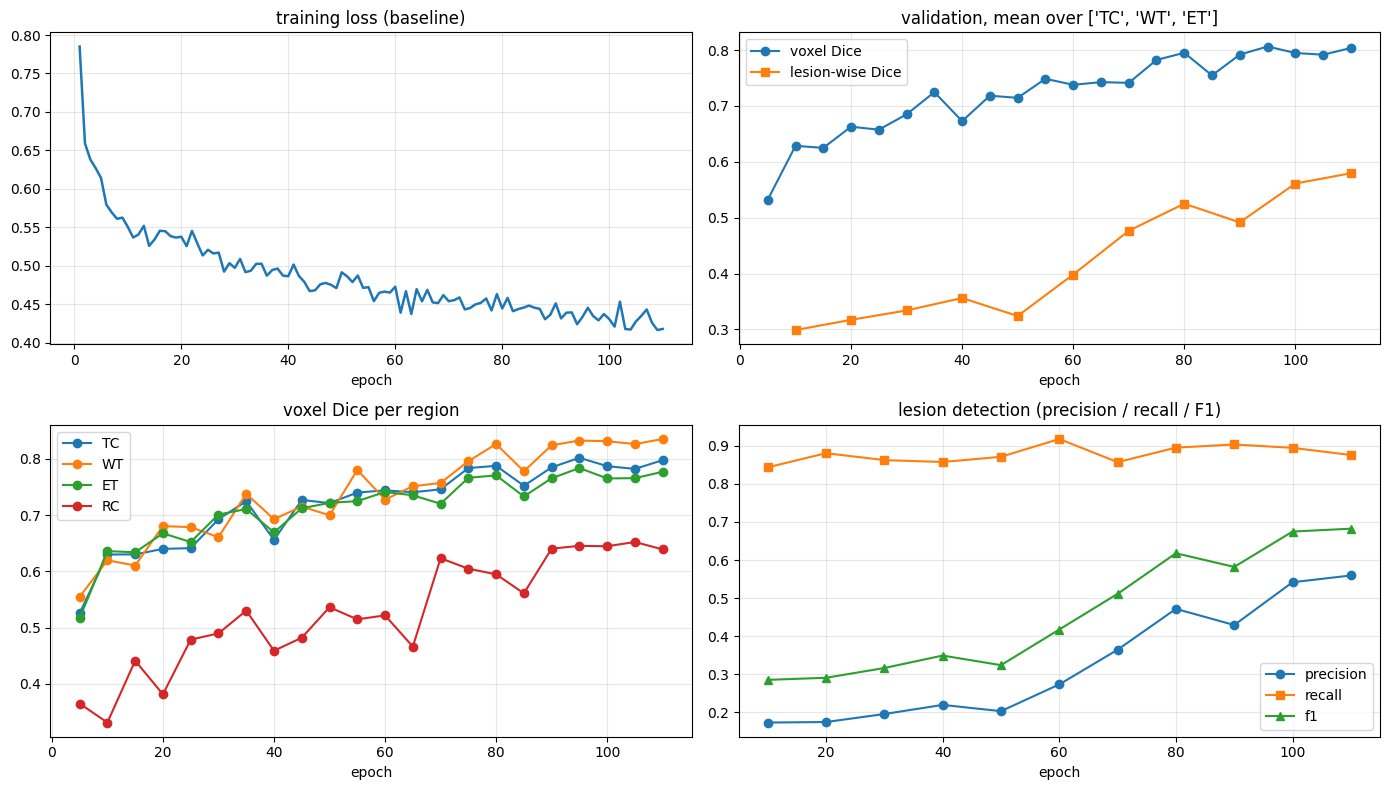

In [20]:
# ---------------------------------------------------------- 9.3 curves
def plot_history(history, save_path=None):
    fig, ax = plt.subplots(2, 2, figsize=(14, 8))
    ax[0, 0].plot(history["epoch"], history["train_loss"], lw=1.8)
    ax[0, 0].set_title(f"training loss ({VARIANT})"); ax[0, 0].grid(alpha=.3)

    ax[0, 1].plot(history["val_epoch"], history["val_select"], "o-",
                  label="voxel Dice")
    if history.get("les_epoch"):
        ax[0, 1].plot(history["les_epoch"], history["les_select"], "s-",
                      label="lesion-wise Dice")
    ax[0, 1].legend(); ax[0, 1].grid(alpha=.3)
    ax[0, 1].set_title(f"validation, mean over {SELECT_REGIONS}")

    if history["val_dice_per_region"]:
        per = np.array(history["val_dice_per_region"], dtype=float)
        for i, n in enumerate(REGION_NAMES):
            ax[1, 0].plot(history["val_epoch"], per[:, i], "o-", label=n)
        ax[1, 0].legend()
    ax[1, 0].set_title("voxel Dice per region"); ax[1, 0].grid(alpha=.3)

    det = history.get("les_detail") or []
    if det:
        ep = history["les_epoch"]
        for m, style in (("precision", "o-"), ("recall", "s-"), ("f1", "^-")):
            ys = [float(np.nanmean([d[n][m] for n in SELECT_REGIONS]))
                  for d in det]
            ax[1, 1].plot(ep, ys, style, label=m)
        ax[1, 1].legend()
    ax[1, 1].set_title("lesion detection (precision / recall / F1)")
    ax[1, 1].grid(alpha=.3)
    for a in ax.ravel():
        a.set_xlabel("epoch")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()


plot_history(history, save_path=RUN_DIR / "training_curves.png")

In [21]:
# ------------------------------- 10.1 collect components from the val split
GATE_CASES = 259          # validation cases used to build the gate dataset


@torch.no_grad()
def collect_records(model, files, cfg, limit=None, desc="collecting"):
    """Run inference and reduce every case to per-region component records."""
    ds = Dataset(data=files[:limit] if limit else files, transform=val_transforms)
    ld = DataLoader(ds, batch_size=1, shuffle=False, num_workers=cfg.num_workers)
    model.eval()
    out = []
    for k, batch in enumerate(tqdm(ld, desc=desc, leave=False)):
        probs = infer_probs(model, batch, cfg)[0].cpu().numpy()
        gt = batch["label"][0].numpy() > 0.5
        img = batch["image"][0].numpy()
        case = {"case_id": batch["case_id"][0], "subset": batch["subset"][0],
                "regions": []}
        for c in range(cfg.out_channels):
            case["regions"].append(
                region_components(probs[c], gt[c], cfg, image=img,
                                  with_features=True, region_idx=c))
        out.append(case)
        del probs, gt, img
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    return out


_ck = BEST_LESION if BEST_LESION.exists() else (
      BEST_CKPT if BEST_CKPT.exists() else BEST_LIGHT)
if _ck.exists():
    _c = load_checkpoint(_ck, model)
    print(f"loaded {_ck.name} (epoch {_c['epoch']+1})")
else:
    print("WARN no checkpoint - using in-memory weights")

val_records = collect_records(model, val_files_full, cfg, limit=GATE_CASES,
                              desc="val -> components")

# stratify the fit/tune split by cohort, otherwise one cohort lands entirely
# on one side and its thresholds cannot be tuned at all
from collections import defaultdict as _dd
_by = _dd(list)
for r in val_records:
    _by[r["subset"]].append(r)
rec_fit, rec_tune = [], []
_rng = np.random.default_rng(SEED)
for s in sorted(_by):
    idx = _rng.permutation(len(_by[s]))
    h = len(idx) // 2
    rec_fit  += [_by[s][int(i)] for i in idx[:h]]
    rec_tune += [_by[s][int(i)] for i in idx[h:]]

print(f"fit : {dict(Counter(c['subset'] for c in rec_fit))}")
print(f"tune: {dict(Counter(c['subset'] for c in rec_tune))}")

loaded best_lesion.pt (epoch 110)


val -> components:   0%|          | 0/259 [00:00<?, ?it/s]

fit : {'BraTS-GLI': 55, 'BraTS-MEN': 55, 'BraTS-PED': 19}
tune: {'BraTS-GLI': 55, 'BraTS-MEN': 55, 'BraTS-PED': 20}


In [22]:
# ------------------------------------------- 10.2 fit the gate classifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import joblib

FEATURE_NAMES = ["region", "volume", "log_volume", "mean_prob", "max_prob",
                 "std_prob", "prob_mass", "fill_ratio", "frac_of_largest",
                 "n_comp", "touches_border"] 


def to_xy(cases):
    X, y = [], []
    for case in cases:
        for rec in case["regions"]:
            for c in rec["comps"]:
                if "f" not in c:
                    continue
                X.append([c["f"].get(k, 0.0) for k in FEATURE_NAMES])
                y.append(1 if c["member"] else 0)      # overlaps a GT lesion
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.int32)


X_fit, y_fit = to_xy(rec_fit)
X_tune, y_tune = to_xy(rec_tune)
print(f"fit  {X_fit.shape}  positives {y_fit.mean():.3f}")
print(f"tune {X_tune.shape}  positives {y_tune.mean():.3f}")

if len(np.unique(y_fit)) < 2 or len(X_tune) == 0:
    print("\nNot enough component variety to fit a gate. Raise GATE_CASES, or "
          "train the segmentation model longer so it produces false positives.")
    gate = None
else:
    gate = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=15,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.15,
        random_state=SEED)
    gate.fit(X_fit, y_fit)
    p_tune = gate.predict_proba(X_tune)[:, 1]
    print(f"\ngate on the tuning half: "
          f"AUC={roc_auc_score(y_tune, p_tune):.4f}  "
          f"AP={average_precision_score(y_tune, p_tune):.4f}")
    joblib.dump({"model": gate, "features": FEATURE_NAMES}, GATE_PATH)
    print(f"saved -> {GATE_PATH}")

fit  (1803, 11)  positives 0.366
tune (1911, 11)  positives 0.357

gate on the tuning half: AUC=0.8242  AP=0.8097
saved -> /kaggle/working/brats_runs/lesionaware_baseline/component_gate.joblib


In [26]:
# ------------------------------ 10.3 choose thresholds on the tuning half
def gate_probs_for_case(case, gate):
    out = []
    for rec in case["regions"]:
        if gate is None or not rec["comps"]:
            out.append(np.ones(len(rec["comps"]), dtype=np.float32))
            continue
        X = np.asarray([[c["f"].get(k, 0.0) for k in FEATURE_NAMES]
                        for c in rec["comps"]], dtype=np.float32)
        out.append(gate.predict_proba(X)[:, 1].astype(np.float32))
    return out


def evaluate(cases, gate=None, tau=None, vol_thresh=None):
    """Score a set of cases under one global filtering rule."""
    rows = []
    for case in cases:
        gp = gate_probs_for_case(case, gate) if tau is not None else None
        for c_i, rec in enumerate(case["regions"]):
            if tau is not None:
                keep = [bool(p >= tau) for p in gp[c_i]]
            elif vol_thresh is not None:
                keep = [c["volume"] >= vol_thresh for c in rec["comps"]]
            else:
                keep = None
            sc = score_record(rec, keep=keep)
            if sc is not None:
                sc["region"] = c_i
                rows.append(sc)
    return aggregate_scores(rows)


# --- baseline rule: one volume threshold, swept on the tuning half ----------
VOL_GRID_G = [0, 10, 25, 50, 100, 200, 400, 800, 1600]
vol_scores = {v: evaluate(rec_tune, vol_thresh=v)["select"] for v in VOL_GRID_G}
best_vol = max(vol_scores, key=lambda v: vol_scores[v])
print(f"{'volume thresh':>14}{'lwDice(select)':>17}")
for v in VOL_GRID_G:
    print(f"{v:>14}{vol_scores[v]:>17.4f}"
          + ("   <-- best" if v == best_vol else ""))

# --- proposed rule: the learned gate, threshold swept the same way ---------
best_tau = None
if gate is not None:
    TAU_GRID_G = [round(float(t), 2) for t in np.arange(0.05, 0.96, 0.05)]
    tau_scores = {t: evaluate(rec_tune, gate=gate, tau=t)["select"]
                  for t in TAU_GRID_G}
    best_tau = max(tau_scores, key=lambda t: tau_scores[t])
    print(f"\n{'gate tau':>14}{'lwDice(select)':>17}")
    for t in TAU_GRID_G:
        print(f"{t:>14.2f}{tau_scores[t]:>17.4f}"
              + ("   <-- best" if t == best_tau else ""))

json.dump({"best_vol_thresh": int(best_vol),
           "best_gate_tau": (float(best_tau) if best_tau is not None else None),
           "gate_cases": GATE_CASES},
          open(RUN_DIR / "gate_thresholds.json", "w"), indent=2)
print(f"\nchosen: volume threshold {best_vol}"
      + (f", gate tau {best_tau}" if best_tau is not None else ""))

 volume thresh   lwDice(select)
             0           0.5280
            10           0.5280
            25           0.5578
            50           0.5853
           100           0.6303
           200           0.6390
           400           0.6581
           800           0.6540
          1600           0.6591   <-- best

      gate tau   lwDice(select)
          0.05           0.5391
          0.10           0.5710
          0.15           0.6189
          0.20           0.6459
          0.25           0.6713
          0.30           0.6971
          0.35           0.7081
          0.40           0.7197
          0.45           0.7283
          0.50           0.7323
          0.55           0.7291
          0.60           0.7347   <-- best
          0.65           0.7326
          0.70           0.7312
          0.75           0.7271
          0.80           0.7212
          0.85           0.7179
          0.90           0.7002
          0.95           0.6635

chosen: volume t

In [28]:
# ---- fair comparison: per-region thresholds for BOTH rules ----------------
from sklearn.ensemble import HistGradientBoostingClassifier

def evaluate_per_region(cases, gate=None, taus=None, vols=None):
    rows = []
    for case in cases:
        gp = gate_probs_for_case(case, gate) if taus is not None else None
        for c_i, rec in enumerate(case["regions"]):
            if taus is not None:
                keep = [bool(p >= taus[c_i]) for p in gp[c_i]]
            elif vols is not None:
                keep = [c["volume"] >= vols[c_i] for c in rec["comps"]]
            else:
                keep = None
            sc = score_record(rec, keep=keep)
            if sc is not None:
                sc["region"] = c_i
                rows.append(sc)
    return aggregate_scores(rows)

VOL_GRID = [0, 25, 50, 100, 200, 400, 800, 1600, 3200]
TAU_GRID = [round(t, 2) for t in np.arange(0.05, 0.96, 0.05)]

# per-region volume thresholds
best_vols = []
for c_i in range(cfg.out_channels):
    scores = {}
    for v in VOL_GRID:
        vv = [0]*cfg.out_channels; vv[c_i] = v
        scores[v] = evaluate_per_region(rec_tune, vols=vv)[REGION_NAMES[c_i]]["dice"]
    best_vols.append(max(scores, key=lambda k: scores[k]))
print("per-region volume thresholds:",
      dict(zip(REGION_NAMES, best_vols)))

# per-region gate thresholds
best_taus = []
for c_i in range(cfg.out_channels):
    scores = {}
    for t in TAU_GRID:
        tt = [0.0]*cfg.out_channels; tt[c_i] = t
        scores[t] = evaluate_per_region(rec_tune, gate=gate, taus=tt)[REGION_NAMES[c_i]]["dice"]
    best_taus.append(max(scores, key=lambda k: scores[k]))
print("per-region gate taus       :", dict(zip(REGION_NAMES, best_taus)))

# ---- diagnostic: can a VOLUME-ONLY gate match the threshold? --------------
vol_idx = FEATURE_NAMES.index("volume")
reg_idx = FEATURE_NAMES.index("region")
g1 = HistGradientBoostingClassifier(max_iter=100, max_leaf_nodes=7,
                                    random_state=SEED)
g1.fit(X_fit[:, [reg_idx, vol_idx]], y_fit)

class VolOnlyGate:
    def predict_proba(self, X):
        return g1.predict_proba(X[:, [reg_idx, vol_idx]])

print("\ntuning-half lwDice(select):")
print(f"  no filtering            {evaluate(rec_tune)['select']:.4f}")
print(f"  volume per-region       "
      f"{evaluate_per_region(rec_tune, vols=best_vols)['select']:.4f}")
print(f"  gate per-region         "
      f"{evaluate_per_region(rec_tune, gate=gate, taus=best_taus)['select']:.4f}")
print(f"  gate (region+volume)    "
      f"{evaluate(rec_tune, gate=VolOnlyGate(), tau=0.5)['select']:.4f}")

per-region volume thresholds: {'TC': 400, 'WT': 1600, 'ET': 400, 'RC': 1600}
per-region gate taus       : {'TC': np.float64(0.6), 'WT': np.float64(0.45), 'ET': np.float64(0.6), 'RC': np.float64(0.6)}

tuning-half lwDice(select):
  no filtering            0.5280
  volume per-region       0.6726
  gate per-region         0.7363
  gate (region+volume)    0.6595


In [30]:
# ---- threshold tuning with 5-fold CV inside the tuning half ---------------
def cv_best(cases, mode, c_i, grid, k=5, gate=None):
    rng = np.random.default_rng(SEED)
    idx = rng.permutation(len(cases))
    folds = [[cases[int(j)] for j in idx[f::k]] for f in range(k)]
    scores = {}
    for v in grid:
        vals = []
        for f in range(k):
            held = folds[f]
            if mode == "vol":
                vv = [0] * cfg.out_channels; vv[c_i] = v
                a = evaluate_per_region(held, vols=vv)
            else:
                tt = [0.0] * cfg.out_channels; tt[c_i] = v
                a = evaluate_per_region(held, gate=gate, taus=tt)
            d = a[REGION_NAMES[c_i]]["dice"]
            if d == d:
                vals.append(d)
        scores[v] = float(np.mean(vals)) if vals else float("nan")
    best = max((v for v in grid if scores[v] == scores[v]),
               key=lambda v: scores[v])
    return best, scores


best_vols, best_taus = [], []
print(f"{'region':<6}{'volume':>9}{'cv dice':>10}{'tau':>8}{'cv dice':>10}")
print("-" * 43)
for c_i, rn in enumerate(REGION_NAMES):
    bv, sv = cv_best(rec_tune, "vol", c_i, VOL_GRID)
    bt, st = cv_best(rec_tune, "tau", c_i, TAU_GRID, gate=gate)
    best_vols.append(bv)
    best_taus.append(float(bt))
    print(f"{rn:<6}{bv:>9}{sv[bv]:>10.4f}{bt:>8.2f}{st[bt]:>10.4f}")

print("\nvolume per-region:", dict(zip(REGION_NAMES, best_vols)))
print("gate   per-region:", dict(zip(REGION_NAMES, best_taus)))

region   volume   cv dice     tau   cv dice
-------------------------------------------
TC          400    0.6518    0.55    0.7354
WT         1600    0.7269    0.45    0.7689
ET          400    0.6336    0.60    0.6994
RC         1600    0.5184    0.60    0.5747

volume per-region: {'TC': 400, 'WT': 1600, 'ET': 400, 'RC': 1600}
gate   per-region: {'TC': 0.55, 'WT': 0.45, 'ET': 0.6, 'RC': 0.6}


In [31]:
# ----------------------------------- 11.1 final table on the held-out test set
TEST_CASES = None          # None = whole test split (293 cases)

test_records = collect_records(model, test_files, cfg, limit=TEST_CASES,
                               desc="test -> components")
print(f"{len(test_records)} test cases | "
      f"{dict(Counter(c['subset'] for c in test_records))}\n")

# ---- the rules being compared ---------------------------------------------
rules = {"no filtering": lambda cs: evaluate(cs)}

rules[f"volume >= {best_vol} (single)"] = \
    lambda cs: evaluate(cs, vol_thresh=best_vol)
if gate is not None and best_tau is not None:
    rules[f"gate tau={best_tau} (single)"] = \
        lambda cs: evaluate(cs, gate=gate, tau=best_tau)

# per-region rules only if the diagnostic cell has been run
if "best_vols" in dir():
    rules["volume per-region"] = \
        lambda cs: evaluate_per_region(cs, vols=best_vols)
if "best_taus" in dir() and gate is not None:
    rules["gate per-region"] = \
        lambda cs: evaluate_per_region(cs, gate=gate, taus=best_taus)

# ---- pooled ----------------------------------------------------------------
print("=" * 78)
print(f"TEST SET - LESION-WISE - variant '{VARIANT}' - {len(test_records)} cases")
print("=" * 78)
rows, results = [], {}
for name, fn in rules.items():
    agg = fn(test_records)
    results[name] = agg
    print(f"\n{name}")
    print(fmt_lesion(agg))
    for n in REGION_NAMES:
        rows.append({"variant": VARIANT, "rule": name, "cohort": "ALL",
                     "region": n,
                     **{k: agg[n][k] for k in
                        ("dice", "precision", "recall", "f1", "tp", "fp", "fn")}})
    rows.append({"variant": VARIANT, "rule": name, "cohort": "ALL",
                 "region": "SELECT", "dice": agg["select"]})

# ---- per cohort - this is the cross-cohort story ---------------------------
cohorts = sorted({c["subset"] for c in test_records})
print("\n" + "=" * 78)
print("PER COHORT (mean lesion-wise Dice over " + ", ".join(SELECT_REGIONS) + ")")
print("=" * 78)
header = f"{'rule':<30}" + "".join(f"{s.replace('BraTS-',''):>12}" for s in cohorts)
print(header)
print("-" * len(header))
for name, fn in rules.items():
    line = f"{name:<30}"
    for s in cohorts:
        sub = [c for c in test_records if c["subset"] == s]
        agg = fn(sub)
        line += f"{agg['select']:>12.4f}"
        for n in REGION_NAMES:
            rows.append({"variant": VARIANT, "rule": name, "cohort": s,
                         "region": n,
                         **{k: agg[n][k] for k in
                            ("dice", "precision", "recall", "f1",
                             "tp", "fp", "fn")}})
        rows.append({"variant": VARIANT, "rule": name, "cohort": s,
                     "region": "SELECT", "dice": agg["select"]})
    print(line)
print("\ncase counts: " +
      "  ".join(f"{s.replace('BraTS-','')}="
                f"{sum(1 for c in test_records if c['subset']==s)}"
                for s in cohorts))

pd.DataFrame(rows).to_csv(RUN_DIR / "test_lesionwise.csv", index=False)
print(f"\nsaved -> {RUN_DIR/'test_lesionwise.csv'}")

print("\nheadline (pooled, mean over " + ", ".join(SELECT_REGIONS) + ")")
for name, agg in results.items():
    print(f"  {name:<32}{agg['select']:.4f}")

test -> components:   0%|          | 0/293 [00:00<?, ?it/s]

293 test cases | {'BraTS-GLI': 141, 'BraTS-MEN': 114, 'BraTS-PED': 38}

TEST SET - LESION-WISE - variant 'baseline' - 293 cases

no filtering
  region   lwDice    prec  recall      F1    TP    FP    FN
  TC       0.5548   0.496   0.884   0.635   334   340    44
  WT       0.5062   0.418   0.894   0.570   338   471    40
  ET       0.5282   0.463   0.875   0.606   323   374    46
  RC       0.2622   0.254   0.877   0.394   107   314    15
  select (mean lwDice over ['TC', 'WT', 'ET']) = 0.5297

volume >= 1600 (single)
  region   lwDice    prec  recall      F1    TP    FP    FN
  TC       0.5731   0.812   0.585   0.680   221    51   157
  WT       0.6667   0.791   0.772   0.782   292    77    86
  ET       0.5336   0.879   0.534   0.664   197    27   172
  RC       0.4249   0.750   0.615   0.676    75    25    47
  select (mean lwDice over ['TC', 'WT', 'ET']) = 0.5912

gate tau=0.6 (single)
  region   lwDice    prec  recall      F1    TP    FP    FN
  TC       0.7045   0.904   0.743   0.


no filtering
quartile  voxel_range  n_lesions   recall
      Q1       51-558        312 0.618590
      Q2     558-5405        310 0.925806
      Q3   5405-26157        311 0.990354
      Q4 26157-321448        314 1.000000

volume >= 1600
quartile  voxel_range  n_lesions   recall
      Q1       51-558        312 0.035256
      Q2     558-5405        310 0.503226
      Q3   5405-26157        311 0.977492
      Q4 26157-321448        314 1.000000

gate tau=0.6
quartile  voxel_range  n_lesions   recall
      Q1       51-558        312 0.272436
      Q2     558-5405        310 0.741935
      Q3   5405-26157        311 0.961415
      Q4 26157-321448        314 0.996815


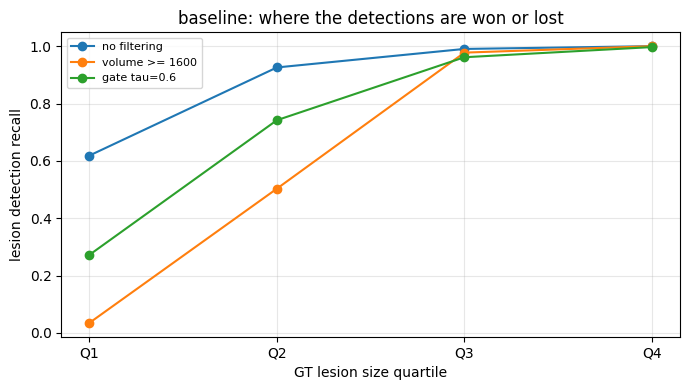

In [32]:
# ------------------------------------- 11.2 recall by lesion-size quartile
# This is the plot that shows WHERE the method helps. If the gain is spread
# evenly across sizes, the small-lesion story in your paper does not hold.
def recall_by_size(cases, gate=None, tau=None, vol_thresh=None, n_bins=4):
    sizes, hit = [], []
    for case in cases:
        gp = gate_probs_for_case(case, gate) if tau is not None else None
        for c_i, rec in enumerate(case["regions"]):
            if tau is not None:
                keep = [bool(p >= tau) for p in gp[c_i]]
            elif vol_thresh is not None:
                keep = [c["volume"] >= vol_thresh for c in rec["comps"]]
            else:
                keep = [True] * len(rec["comps"])
            kept = [c for c, k in zip(rec["comps"], keep)
                    if k and c["volume"] >= cfg.lw_min_pred]
            for i, sz in rec["gt_sizes"].items():
                sizes.append(sz)
                hit.append(1 if any(i in c["member"] for c in kept) else 0)
    if not sizes:
        return None
    sizes, hit = np.array(sizes, float), np.array(hit, float)
    qs = np.quantile(sizes, np.linspace(0, 1, n_bins + 1))
    qs[-1] += 1
    out = []
    for b in range(n_bins):
        m = (sizes >= qs[b]) & (sizes < qs[b + 1])
        out.append({"quartile": f"Q{b+1}",
                    "voxel_range": f"{int(qs[b])}-{int(qs[b+1])}",
                    "n_lesions": int(m.sum()),
                    "recall": float(hit[m].mean()) if m.any() else float("nan")})
    return pd.DataFrame(out)


tbl = {"no filtering": recall_by_size(test_records),
       f"volume >= {best_vol}": recall_by_size(test_records, vol_thresh=best_vol)}
if gate is not None and best_tau is not None:
    tbl[f"gate tau={best_tau}"] = recall_by_size(test_records, gate=gate,
                                                 tau=best_tau)

for name, t in tbl.items():
    if t is None:
        continue
    print(f"\n{name}")
    print(t.to_string(index=False))

base = tbl["no filtering"]
if base is not None:
    fig, ax = plt.subplots(figsize=(7, 4))
    for name, t in tbl.items():
        if t is not None:
            ax.plot(t["quartile"], t["recall"], "o-", label=name)
    ax.set_ylabel("lesion detection recall"); ax.set_xlabel("GT lesion size quartile")
    ax.set_title(f"{VARIANT}: where the detections are won or lost")
    ax.grid(alpha=.3); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(RUN_DIR / "recall_by_size.png", dpi=130, bbox_inches="tight")
    plt.show()
    pd.concat([t.assign(rule=n) for n, t in tbl.items() if t is not None]) \
      .to_csv(RUN_DIR / "recall_by_size.csv", index=False)

In [33]:
# --------------------------------- 12.1 compare every variant you have run
rows = []
for d in sorted(Path(cfg.work_dir).glob("lesionaware_*")):
    f = d / "test_lesionwise.csv"
    if not f.exists():
        continue
    t = pd.read_csv(f)
    sel = t[t["region"] == "SELECT"]
    for _, r in sel.iterrows():
        rows.append({"variant": r["variant"], "rule": r["rule"],
                     "lesion_dice_select": round(float(r["dice"]), 4)})
if rows:
    piv = pd.DataFrame(rows).pivot_table(index="variant", columns="rule",
                                         values="lesion_dice_select")
    print("mean lesion-wise Dice over " + ", ".join(SELECT_REGIONS))
    print(piv.round(4).to_string())
    piv.to_csv(Path(cfg.work_dir) / "ablation_summary.csv")
    print(f"\nsaved -> {Path(cfg.work_dir)/'ablation_summary.csv'}")
else:
    print("No finished variants yet. Run 'baseline' and at least one 'cc_*', "
          "then re-run this cell.")

import os
os.chdir("/kaggle/working")
print(f"\nfiles in {RUN_DIR}")
for p in sorted(RUN_DIR.iterdir()):
    print(f"  {p.name:<30}{p.stat().st_size/1024**2:>9.1f} MB")
from IPython.display import FileLink, display
for f in ["best_lesion.pt", "best_weights.pt", "component_gate.joblib",
          "test_lesionwise.csv", "recall_by_size.csv", "gate_thresholds.json",
          "history.json"]:
    if (RUN_DIR / f).exists():
        display(FileLink(str((RUN_DIR / f).relative_to("/kaggle/working"))))

mean lesion-wise Dice over TC, WT, ET
rule      gate per-region  gate tau=0.6 (single)  no filtering  volume >= 1600 (single)  volume per-region
variant                                                                                                   
baseline           0.6929                 0.6954        0.4953                   0.5704             0.6209

saved -> /kaggle/working/brats_runs/ablation_summary.csv

files in /kaggle/working/brats_runs/lesionaware_baseline
  best.pt                           126.3 MB
  best_lesion.pt                    126.3 MB
  best_weights.pt                    63.2 MB
  component_gate.joblib               0.2 MB
  gate_thresholds.json                0.0 MB
  history.json                        0.0 MB
  last.pt                           126.3 MB
  recall_by_size.csv                  0.0 MB
  recall_by_size.png                  0.1 MB
  splits.json                         0.1 MB
  test_lesionwise.csv                 0.0 MB
  three_cohort_examples.png   

/kaggle/working/brats_runs/lesionaware_baseline/best_lesion.pt

/kaggle/working/brats_runs/lesionaware_baseline/best_weights.pt

/kaggle/working/brats_runs/lesionaware_baseline/component_gate.joblib

/kaggle/working/brats_runs/lesionaware_baseline/test_lesionwise.csv

/kaggle/working/brats_runs/lesionaware_baseline/recall_by_size.csv

/kaggle/working/brats_runs/lesionaware_baseline/gate_thresholds.json

/kaggle/working/brats_runs/lesionaware_baseline/history.json

In [34]:
# tuning half-la RC GT evlo periya-dhu?
sizes = []
for c in rec_tune:
    rec = c["regions"][3]
    for i, s in rec["gt_sizes"].items():
        sizes.append(s)
print(f"RC GT lesions passing lw_min_gt={cfg.lw_min_gt}: {len(sizes)}")

# raw-a paarunga: dilation/min_gt-ku munnadi
import numpy as np
n_gli = sum(1 for c in rec_tune if c["subset"] == "BraTS-GLI")
print(f"GLI cases in tuning half: {n_gli} / {len(rec_tune)}")

RC GT lesions passing lw_min_gt=50: 49
GLI cases in tuning half: 55 / 130


BraTS-GLI / BraTS-GLI-02216-100
Whole tumour          40.95 cc
Tumour core            4.31 cc
Enhancing              4.08 cc
Non-enh. core          0.23 cc
Oedema / SNFH         36.64 cc
Resection cavity       1.61 cc

mask -> /kaggle/temp/predictions/BraTS-GLI-02216-100_pred_seg.nii.gz


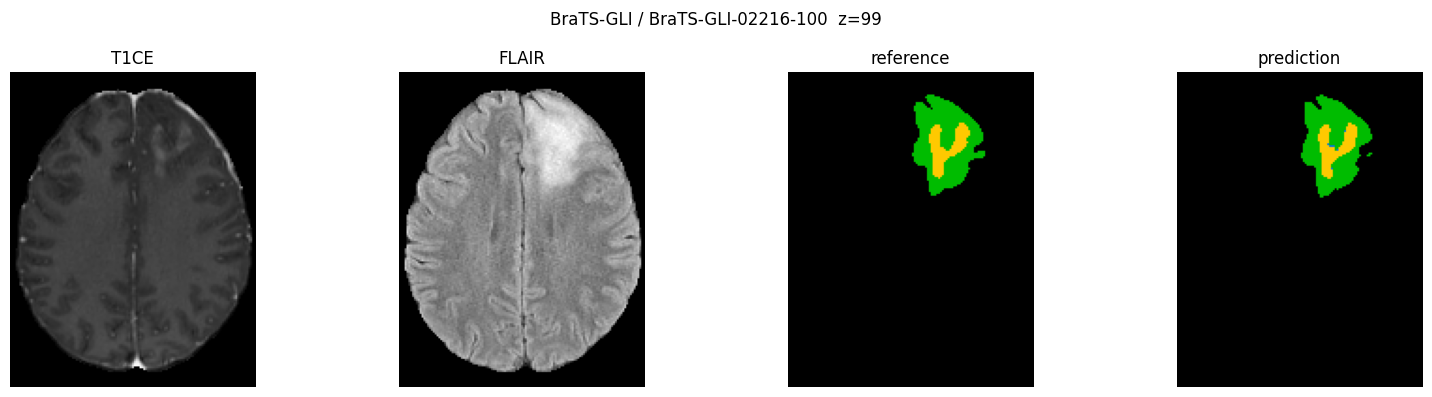

In [35]:
# ------------------------------- 13.1 predict one case and write a NIfTI
def regions_to_labelmap(pred):
    """[TC, WT, ET, RC] binary channels -> canonical label map {0,1,2,3,4}.

    Enforces ET c TC c WT, and never lets the resection cavity overwrite
    tumour tissue.
    """
    tc, wt, et, rc = (pred[0] > 0.5, pred[1] > 0.5, pred[2] > 0.5, pred[3] > 0.5)
    tc = tc | et
    wt = wt | tc
    out = np.zeros(wt.shape, dtype=np.uint8)
    out[wt & ~tc] = 2
    out[tc & ~et] = 1
    out[et] = 3
    out[rc & (out == 0)] = 4
    return out


def apply_gate_to_labelmap(prob, gate, tau, cfg):
    """Run the learned gate, then build the label map from the kept components."""
    kept = np.zeros_like(prob, dtype=bool)
    for c in range(prob.shape[0]):
        rec = region_components(prob[c], np.zeros(prob[c].shape, bool), cfg,
                                image=None, with_features=True, region_idx=c)
        binm = prob[c] > 0.5
        if not rec["comps"] or gate is None or tau is None:
            kept[c] = binm
            continue
        lab, _ = ndi.label(binm, structure=CONN26)
        X = np.asarray([[cc["f"].get(k, 0.0) for k in FEATURE_NAMES]
                        for cc in rec["comps"]], dtype=np.float32)
        p = gate.predict_proba(X)[:, 1]
        keep_ids = [cc["id"] for cc, pi in zip(rec["comps"], p)
                    if pi >= tau and cc["volume"] >= cfg.lw_min_pred]
        kept[c] = np.isin(lab, keep_ids) if keep_ids else np.zeros_like(binm)
    return kept


@torch.no_grad()
def predict_case(model, record, cfg, gate=None, tau=None,
                 out_dir=Path("/kaggle/temp/predictions")):
    model.eval()
    data = val_transforms({"npz": record["npz"], "case_id": record["case_id"],
                           "subset": record["subset"]})
    img = data["image"].unsqueeze(0).to(DEVICE)
    with autocast_ctx():
        logits = sliding_window_inference(img, cfg.roi, cfg.sw_batch_size, model,
                                          overlap=cfg.sw_overlap, mode="gaussian")
    prob = torch.sigmoid(logits.float())[0].cpu().numpy()

    binm = (apply_gate_to_labelmap(prob, gate, tau, cfg)
            if gate is not None and tau is not None else prob > 0.5)
    labelmap = regions_to_labelmap(binm.astype(np.float32))

    affine = np.asarray(data["affine"], dtype=np.float64)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{record['case_id']}_pred_seg.nii.gz"
    nib.save(nib.Nifti1Image(labelmap, affine), str(out_path))

    vox_cc = float(abs(np.linalg.det(affine[:3, :3]))) / 1000.0
    n = {k: int((labelmap == v).sum())
         for k, v in (("NETC", 1), ("ED", 2), ("ET", 3), ("RC", 4))}
    n["TC"] = n["NETC"] + n["ET"]
    n["WT"] = n["NETC"] + n["ED"] + n["ET"]
    vols = {k: round(v * vox_cc, 2) for k, v in n.items()}
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return {"case_id": record["case_id"], "subset": record["subset"],
            "labelmap": labelmap, "affine": affine, "volumes_cc": vols,
            "nifti_path": str(out_path)}


assert test_files, "test split is empty"
_case = test_files[0]
_res = predict_case(model, _case, cfg,
                    gate=gate if 'gate' in dir() else None,
                    tau=best_tau if 'best_tau' in dir() else None)

print("=" * 62)
print(f"{_res['subset']} / {_res['case_id']}")
print("=" * 62)
for k, lbl in (("WT", "Whole tumour"), ("TC", "Tumour core"),
               ("ET", "Enhancing"), ("NETC", "Non-enh. core"),
               ("ED", "Oedema / SNFH"), ("RC", "Resection cavity")):
    print(f"{lbl:<18}{_res['volumes_cc'][k]:>9.2f} cc")
print(f"\nmask -> {_res['nifti_path']}")

# ---- visual check ----------------------------------------------------------
_z = np.load(_case["npz"])
_img, _gt = _z["image"].astype(np.float32), _z["label"]
_k = int(np.argmax(_gt.sum(axis=(0, 1)))) if _gt.any() else _gt.shape[2] // 2
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, (arr, ttl, cm) in zip(ax, [
        (_img[1, :, :, _k], "T1CE", "gray"),
        (_img[3, :, :, _k], "FLAIR", "gray"),
        (_gt[:, :, _k], "reference", "nipy_spectral"),
        (_res["labelmap"][:, :, _k], "prediction", "nipy_spectral")]):
    a.imshow(np.rot90(arr), cmap=cm, vmin=0, vmax=(4 if cm != "gray" else None))
    a.set_title(ttl); a.axis("off")
fig.suptitle(f"{_res['subset']} / {_res['case_id']}  z={_k}")
plt.tight_layout(); plt.show()

In [36]:
# ---- per-case lesion-wise Dice under any filtering rule -------------------
def per_case_select(cases, **kw):
    out = []
    for c in cases:
        rows = []
        gp = gate_probs_for_case(c, kw.get("gate")) if "taus" in kw else None
        for c_i, rec in enumerate(c["regions"]):
            if "taus" in kw:
                keep = [bool(p >= kw["taus"][c_i]) for p in gp[c_i]]
            elif "vols" in kw:
                keep = [x["volume"] >= kw["vols"][c_i] for x in rec["comps"]]
            else:
                keep = None
            sc = score_record(rec, keep=keep)
            if sc is not None:
                sc["region"] = c_i
                rows.append(sc)
        out.append(aggregate_scores(rows)["select"] if rows else np.nan)
    return np.array(out, dtype=float)

print("per_case_select ready")

per_case_select ready


In [37]:
a2 = per_case_select(test_records,
                     vols=[best_vol] * cfg.out_channels)   # single 400
b  = per_case_select(test_records, gate=gate, taus=best_taus)
m = np.isfinite(a2) & np.isfinite(b)
a2, b = a2[m], b[m]
d2 = b - a2

rng = np.random.default_rng(SEED)
boot = np.array([d2[rng.integers(0, len(d2), len(d2))].mean()
                 for _ in range(10000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
from scipy.stats import wilcoxon
_, p = wilcoxon(b, a2)

print(f"volume single ({best_vol}) : {a2.mean():.4f}")
print(f"gate per-region           : {b.mean():.4f}")
print(f"difference                : {d2.mean():+.4f}  "
      f"95% CI [{lo:+.4f}, {hi:+.4f}]")
print(f"Wilcoxon p = {p:.2e}")
print("\nSIGNIFICANT" if lo > 0 else "\nNOT significant")

/tmp/ipykernel_58/2200146667.py:140: RuntimeWarning: Mean of empty slice
  out["select"] = float(np.nanmean(sel_d))
/tmp/ipykernel_58/2200146667.py:140: RuntimeWarning: Mean of empty slice
  out["select"] = float(np.nanmean(sel_d))
/tmp/ipykernel_58/2200146667.py:140: RuntimeWarning: Mean of empty slice
  out["select"] = float(np.nanmean(sel_d))


volume single (1600) : 0.6015
gate per-region           : 0.7117
difference                : +0.1102  95% CI [+0.0816, +0.1414]
Wilcoxon p = 5.42e-12

SIGNIFICANT


In [38]:
for s in sorted({c["subset"] for c in test_records}):
    sub = [c for c in test_records if c["subset"] == s]
    aa = per_case_select(sub, vols=[best_vol] * cfg.out_channels)
    bb = per_case_select(sub, gate=gate, taus=best_taus)
    mm = np.isfinite(aa) & np.isfinite(bb)
    dd = bb[mm] - aa[mm]
    bt = np.array([dd[rng.integers(0, len(dd), len(dd))].mean()
                   for _ in range(10000)])
    lo_, hi_ = np.percentile(bt, [2.5, 97.5])
    print(f"{s:<12} n={len(dd):>4}  vol={aa[mm].mean():.4f}  "
          f"gate={bb[mm].mean():.4f}  diff={dd.mean():+.4f}  "
          f"CI [{lo_:+.4f}, {hi_:+.4f}]")

/tmp/ipykernel_58/2200146667.py:140: RuntimeWarning: Mean of empty slice
  out["select"] = float(np.nanmean(sel_d))
/tmp/ipykernel_58/2200146667.py:140: RuntimeWarning: Mean of empty slice
  out["select"] = float(np.nanmean(sel_d))
/tmp/ipykernel_58/2200146667.py:140: RuntimeWarning: Mean of empty slice
  out["select"] = float(np.nanmean(sel_d))


BraTS-GLI    n= 139  vol=0.5832  gate=0.6494  diff=+0.0662  CI [+0.0386, +0.0944]
BraTS-MEN    n= 113  vol=0.6539  gate=0.8034  diff=+0.1495  CI [+0.0886, +0.2158]
BraTS-PED    n=  38  vol=0.5126  gate=0.6668  diff=+0.1542  CI [+0.0887, +0.2230]


In [39]:
# ---- does the gate depend on its random seed? -----------------------------
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

rows = []
for s in (0, 42, 1234, 2026, 7):
    g = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=15,
        l2_regularization=1.0, early_stopping=True,
        validation_fraction=0.15, random_state=s)
    g.fit(X_fit, y_fit)
    p = g.predict_proba(X_tune)[:, 1]
    rows.append({
        "seed": s,
        "auc": roc_auc_score(y_tune, p),
        "ap": average_precision_score(y_tune, p),
        "test_select": evaluate_per_region(test_records, gate=g,
                                           taus=best_taus)["select"],
    })

df = pd.DataFrame(rows)
print(df.round(4).to_string(index=False))

v = df["test_select"].values
print(f"\ngate per-region, test  : {v.mean():.4f} +/- {v.std():.4f}"
      f"   (min {v.min():.4f}, max {v.max():.4f})")
print(f"volume per-region, test: "
      f"{evaluate_per_region(test_records, vols=best_vols)['select']:.4f}")
print(f"volume single ({best_vol}), test : "
      f"{evaluate(test_records, vol_thresh=best_vol)['select']:.4f}")
print(f"\nworst seed still beats the strongest volume rule: "
      f"{v.min() > evaluate(test_records, vol_thresh=best_vol)['select']}")

 seed    auc     ap  test_select
    0 0.8117 0.8059       0.7024
   42 0.8242 0.8097       0.7089
 1234 0.8151 0.8020       0.7063
 2026 0.8215 0.8028       0.6965
    7 0.8256 0.8144       0.6988

gate per-region, test  : 0.7026 +/- 0.0046   (min 0.6965, max 0.7089)
volume per-region, test: 0.6493
volume single (1600), test : 0.5912

worst seed still beats the strongest volume rule: True


In [40]:
from sklearn.inspection import permutation_importance
r = permutation_importance(gate, X_tune, y_tune, n_repeats=10,
                           random_state=SEED, scoring="average_precision")
order = np.argsort(r.importances_mean)[::-1]
print(f"{'feature':<18}{'drop in AP':>12}{'std':>8}")
print("-" * 38)
for i in order:
    print(f"{FEATURE_NAMES[i]:<18}{r.importances_mean[i]:>12.4f}"
          f"{r.importances_std[i]:>8.4f}")

feature             drop in AP     std
--------------------------------------
mean_prob               0.2405  0.0195
max_prob                0.0242  0.0034
frac_of_largest         0.0230  0.0020
prob_mass               0.0186  0.0067
volume                  0.0060  0.0013
fill_ratio              0.0056  0.0027
touches_border          0.0036  0.0014
region                  0.0028  0.0010
std_prob                0.0010  0.0009
log_volume              0.0000  0.0000
n_comp                 -0.0055  0.0040


In [41]:
GROUPS = {
    "volume only":        ["region", "volume", "log_volume"],
    "+ probability":      ["region", "volume", "log_volume", "mean_prob",
                           "max_prob", "std_prob", "prob_mass"],
    "+ shape":            ["region", "volume", "log_volume", "mean_prob",
                           "max_prob", "std_prob", "prob_mass",
                           "fill_ratio", "frac_of_largest", "n_comp",
                           "touches_border"],
    "+ intensity (all)":  FEATURE_NAMES,
}

print(f"{'feature set':<22}{'n feat':>8}{'AP':>8}{'test lwDice':>13}")
print("-" * 51)
for name, feats in GROUPS.items():
    idx = [FEATURE_NAMES.index(f) for f in feats]

    class Sub:
        def __init__(self, m, idx): self.m, self.idx = m, idx
        def predict_proba(self, X): return self.m.predict_proba(X[:, self.idx])

    g = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=15,
        l2_regularization=1.0, early_stopping=True,
        validation_fraction=0.15, random_state=SEED)
    g.fit(X_fit[:, idx], y_fit)
    ap = average_precision_score(y_tune, g.predict_proba(X_tune[:, idx])[:, 1])
    d = evaluate_per_region(test_records, gate=Sub(g, idx),
                            taus=best_taus)["select"]
    print(f"{name:<22}{len(feats):>8}{ap:>8.4f}{d:>13.4f}")

print(f"\n{'volume >= 400 (rule)':<22}{'-':>8}{'-':>8}"
      f"{evaluate(test_records, vol_thresh=best_vol)['select']:>13.4f}")

feature set             n feat      AP  test lwDice
---------------------------------------------------
volume only                  3  0.7395       0.5998
+ probability                7  0.7989       0.6990
+ shape                     11  0.8097       0.7089
+ intensity (all)           11  0.8097       0.7089

volume >= 400 (rule)         -       -       0.5912


BraTS-GLI    BraTS-GLI-02216-100
BraTS-MEN    BraTS-MEN-00177-000
BraTS-PED    BraTS-PED-00020-000

PER-CASE RESULTS   (gate ON)

BraTS-GLI  /  BraTS-GLI-02216-100
  volumes (cc)      predicted  reference
  NETC                   0.23       0.00
  ED                    36.64      36.23
  ET                     4.08       4.20
  RC                     1.61       1.47
  region      voxel Dice   lwDice   TP   FP   FN
  TC              0.9090   0.9090    1    0    0
  WT              0.9457   0.9457    1    0    0
  ET              0.9109   0.9109    1    0    0
  RC              0.8227   0.8227    1    0    0

BraTS-MEN  /  BraTS-MEN-00177-000
  volumes (cc)      predicted  reference
  NETC                   0.37       0.78
  ED                     3.79       0.00
  ET                    20.13      20.19
  RC                     0.00       0.00
  region      voxel Dice   lwDice   TP   FP   FN
  TC              0.9758   0.9758    1    0    0
  WT              0.9093   0.9093    1    0    0

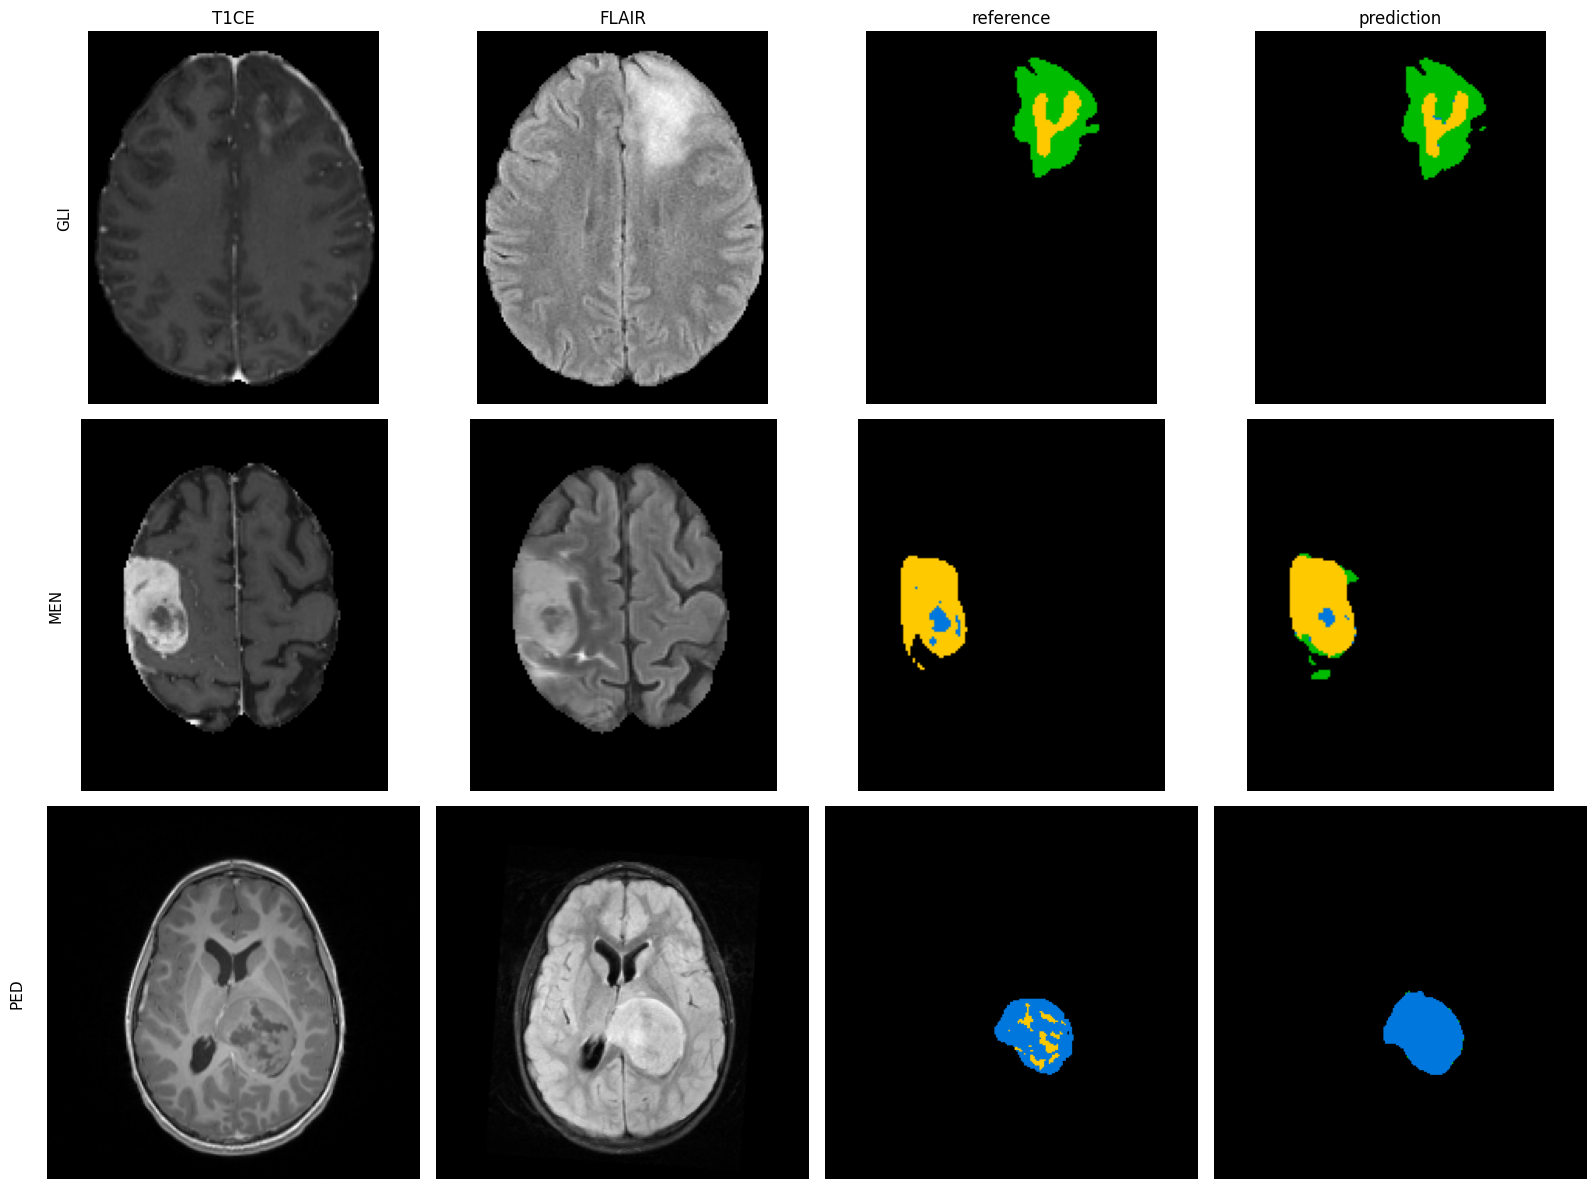


saved -> /kaggle/working/brats_runs/lesionaware_baseline/three_cohort_examples.png


In [42]:
# ---------------- one test case per cohort: GLI, MEN, PED -----------------
import matplotlib.pyplot as plt

USE_GATE = True          # False = raw prediction, no component filtering

def voxel_dice(pred_bin, gt_bin):
    d = pred_bin.sum() + gt_bin.sum()
    return float("nan") if d == 0 else float(2 * (pred_bin & gt_bin).sum() / d)


def pick_case(cohort):
    """first test case of this cohort that actually has tumour"""
    for r in test_files:
        if r["subset"] != cohort:
            continue
        lab = np.load(r["npz"])["label"]
        if (lab > 0).sum() > 500:
            return r
    return None


@torch.no_grad()
def run_one(record):
    data = val_transforms({"npz": record["npz"], "case_id": record["case_id"],
                           "subset": record["subset"]})
    img = data["image"].unsqueeze(0).to(DEVICE)
    with autocast_ctx():
        logits = sliding_window_inference(img, cfg.roi, cfg.sw_batch_size,
                                          model, overlap=cfg.sw_overlap,
                                          mode="gaussian")
    prob = torch.sigmoid(logits.float())[0].cpu().numpy()
    gt4 = data["label"].numpy() > 0.5

    binm = (apply_gate_to_labelmap(prob, gate, best_tau, cfg)
            if USE_GATE and gate is not None else prob > 0.5)

    vox = [voxel_dice(binm[c], gt4[c]) for c in range(cfg.out_channels)]
    les = []
    for c in range(cfg.out_channels):
        rec = region_components(binm[c].astype(np.float32), gt4[c], cfg,
                                region_idx=c)
        sc = score_record(rec)
        les.append(sc if sc else None)

    labelmap = regions_to_labelmap(binm.astype(np.float32))
    z = np.load(record["npz"])
    del img, logits
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return {"rec": record, "pred": labelmap, "gt": z["label"],
            "img": z["image"].astype(np.float32),
            "affine": np.asarray(z["affine"]), "vox": vox, "les": les}


results3 = {}
for cohort in ["BraTS-GLI", "BraTS-MEN", "BraTS-PED"]:
    r = pick_case(cohort)
    if r is None:
        print(f"{cohort}: no suitable test case")
        continue
    results3[cohort] = run_one(r)
    print(f"{cohort:<12} {r['case_id']}")

# ---------------- report ---------------------------------------------------
print("\n" + "=" * 78)
print(f"PER-CASE RESULTS   (gate {'ON' if USE_GATE else 'OFF'})")
print("=" * 78)
for cohort, e in results3.items():
    print(f"\n{cohort}  /  {e['rec']['case_id']}")
    vox_cc = abs(np.linalg.det(e["affine"][:3, :3])) / 1000.0
    n = {k: int((e["pred"] == v).sum())
         for k, v in (("NETC", 1), ("ED", 2), ("ET", 3), ("RC", 4))}
    g = {k: int((e["gt"] == v).sum())
         for k, v in (("NETC", 1), ("ED", 2), ("ET", 3), ("RC", 4))}
    print(f"  {'volumes (cc)':<16}{'predicted':>11}{'reference':>11}")
    for k in ("NETC", "ED", "ET", "RC"):
        print(f"  {k:<16}{n[k]*vox_cc:>11.2f}{g[k]*vox_cc:>11.2f}")
    print(f"  {'region':<10}{'voxel Dice':>12}{'lwDice':>9}"
          f"{'TP':>5}{'FP':>5}{'FN':>5}")
    for c, rn in enumerate(REGION_NAMES):
        v = e["vox"][c]
        l = e["les"][c]
        vs = "   n/a" if v != v else f"{v:>12.4f}"
        ls = ("      n/a" if l is None
              else f"{l['dice']:>9.4f}{l['tp']:>5}{l['fp']:>5}{l['fn']:>5}")
        print(f"  {rn:<10}{vs}{ls}")

# ---------------- pictures -------------------------------------------------
fig, axes = plt.subplots(len(results3), 4, figsize=(16, 4 * len(results3)))
if len(results3) == 1:
    axes = axes[None, :]
for row, (cohort, e) in enumerate(results3.items()):
    gt = e["gt"]
    k = int(np.argmax(gt.sum(axis=(0, 1)))) if gt.any() else gt.shape[2] // 2
    panes = [(e["img"][1, :, :, k], "T1CE", "gray"),
             (e["img"][3, :, :, k], "FLAIR", "gray"),
             (gt[:, :, k], "reference", "nipy_spectral"),
             (e["pred"][:, :, k], "prediction", "nipy_spectral")]
    for col, (arr, ttl, cm) in enumerate(panes):
        ax = axes[row, col]
        ax.imshow(np.rot90(arr), cmap=cm,
                  vmin=None if cm == "gray" else 0,
                  vmax=None if cm == "gray" else 4)
        ax.axis("off")
        if row == 0:
            ax.set_title(ttl)
        if col == 0:
            ax.text(-0.08, 0.5, cohort.replace("BraTS-", ""),
                    transform=ax.transAxes, rotation=90,
                    va="center", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig(RUN_DIR / "three_cohort_examples.png", dpi=130,
            bbox_inches="tight")
plt.show()
print(f"\nsaved -> {RUN_DIR/'three_cohort_examples.png'}")